# Analyse the formation of Pancake ice in the Antarctic MIZ


In [1]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

### USER EDIT start
esm_file = "/scratch/ps29/nd0349/access-om3/archive/MCW-100km_jra_iaf-2010-icdr-weld/experiment_datastore.json"
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams["figure.dpi"]= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-analysis-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /scratch/ps29/nd0349/access-om3/archive/MCW-100km_jra_iaf-2010-icdr-weld/experiment_datastore.json
Plot folder path:  /g/data/ps29/nd0349/access-om3-analysis-figs/


In [4]:
from intake import cat
from xarray import DataTree, map_over_datasets
from distributed import Client
import glob
import xarray as xr
import cf_xarray
import numpy as np
from datetime import timedelta
import cf_xarray as cfxr
import xesmf
import re
import os
import time
import intake


# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.lines as mlines
import cartopy.feature as cft

# Import my functions
functions_path = os.path.abspath("/home/566/nd0349/access-om3-analysis/functions")
if functions_path not in sys.path:
    sys.path.append(functions_path)
from get_files import *
from plot_settings import *
from fstd import *
from parameters import *
π = np.pi
test()

Functions from get_files.py imported!


In [5]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34873 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34873/status,
Dashboard: /proxy/34873/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45149,Workers: 0
Dashboard: /proxy/34873/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37887,Total threads: 1
Dashboard: /proxy/38465/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:40053,


In [6]:
print(client.dashboard_link)

/proxy/34873/status


### Open the intake-esm datastore

In [7]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)


### What ocean variables are available at monthly frequency?

In [8]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [9]:
datastore_filtered = datastore.search(realm="seaIce", frequency="1day")

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
ANGLE,angle grid makes with latitude line on U grid,,,radians
ANGLET,angle grid makes with latitude line on T grid,,,radians
NCAT,category maximum thickness,,,m
VGRDa,vertical snow-ice-bio levels,,,1
VGRDb,vertical ice-bio levels,,,1
VGRDi,vertical ice levels,,,1
VGRDs,vertical snow levels,,,1
afsd,areal floe size distribution,,time: mean,1/m
afsdn,areal floe size and thickness distribution,,time: mean,1/m


### Load in daily AFSDN

In [10]:
ds = datastore.search(variable=["aice", "fsdrad", "afsd", "afsdn", "TLAT", "TLON", "dafsd_wave", "dafsd_newi", "dafsd_weld"], frequency="1day").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"nj": -1, "ni": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

ds_grid = datastore.search(variable=["tarea", "HTE", "NFSD"], frequency="fx", realm="seaIce").to_dask().compute()
coords = datastore.search(variable=["TLAT", "TLON"], #file_id='access_om3_mom6_static'
                         ).to_dask().compute() # TODO why do we need file_id for my runs??
coords = coords.fillna(0.0)
# coords = coords.rename({'geolat': 'lat', 'geolon': 'lon'})
ds = xr.merge([ds, ds_grid])
# ds = ds.assign_coords(coords)
coords = datastore.search(variable=["geolat", "geolon"], file_id="access_om3_mom6_static").to_dask().compute()
coords = coords.fillna(0.0)

ds = ds.assign_coords(coords)
ds = ds.rename({"xh": "ni", "yh": "nj"})
# ds = ds.roll(ni=80, roll_coords=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [11]:
ds

<xarray.Dataset> Size: 113GB
Dimensions:     (time: 1186, nj: 300, ni: 360, nf: 12, nc: 5)
Coordinates: (12/14)
  * time        (time) datetime64[ns] 9kB 2010-01-01T12:00:00 ... 2013-03-31T...
    NCAT        (nc) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    TLON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    TLAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ...          ...
    ELON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ELAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
  * ni          (ni) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
  * nj          (nj) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
    geolon      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 79.96 79.97 79.99
    geolat      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 66.04 65.63 65.21
Dimensions without coordinates: nf, nc
Data variables:
    fsdrad      (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    aice        (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    afsd        (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_wave  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    afsdn       (time, nc, nf, nj, ni) float64 61GB dask.array<chunksize=(11, 1, 4, 300, 360), meta=np.ndarray>
    dafsd_weld  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_newi  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    NFSD        (nf) float64 96B 2.688 9.798 21.67 40.73 ... 506.2 668.2 850.5
    tarea       (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    HTE         (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/19)
    title:                                    access-om3
    contents:                                 Diagnostic and Prognostic Varia...
    source:                                   CICE Sea Ice Model, unknown_ver...
    time_period_freq:                         day_1
    time_axis_position:                       middle
    Conventions:                              CF-1.8
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,time: mean,time: mean,t...
    intake_esm_attrs:variable_units:          days since 2010-01-01 00:00:00,...
    intake_esm_attrs:realm:                   seaIce
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   access_om3_cice_1day_mean_XXXX_...

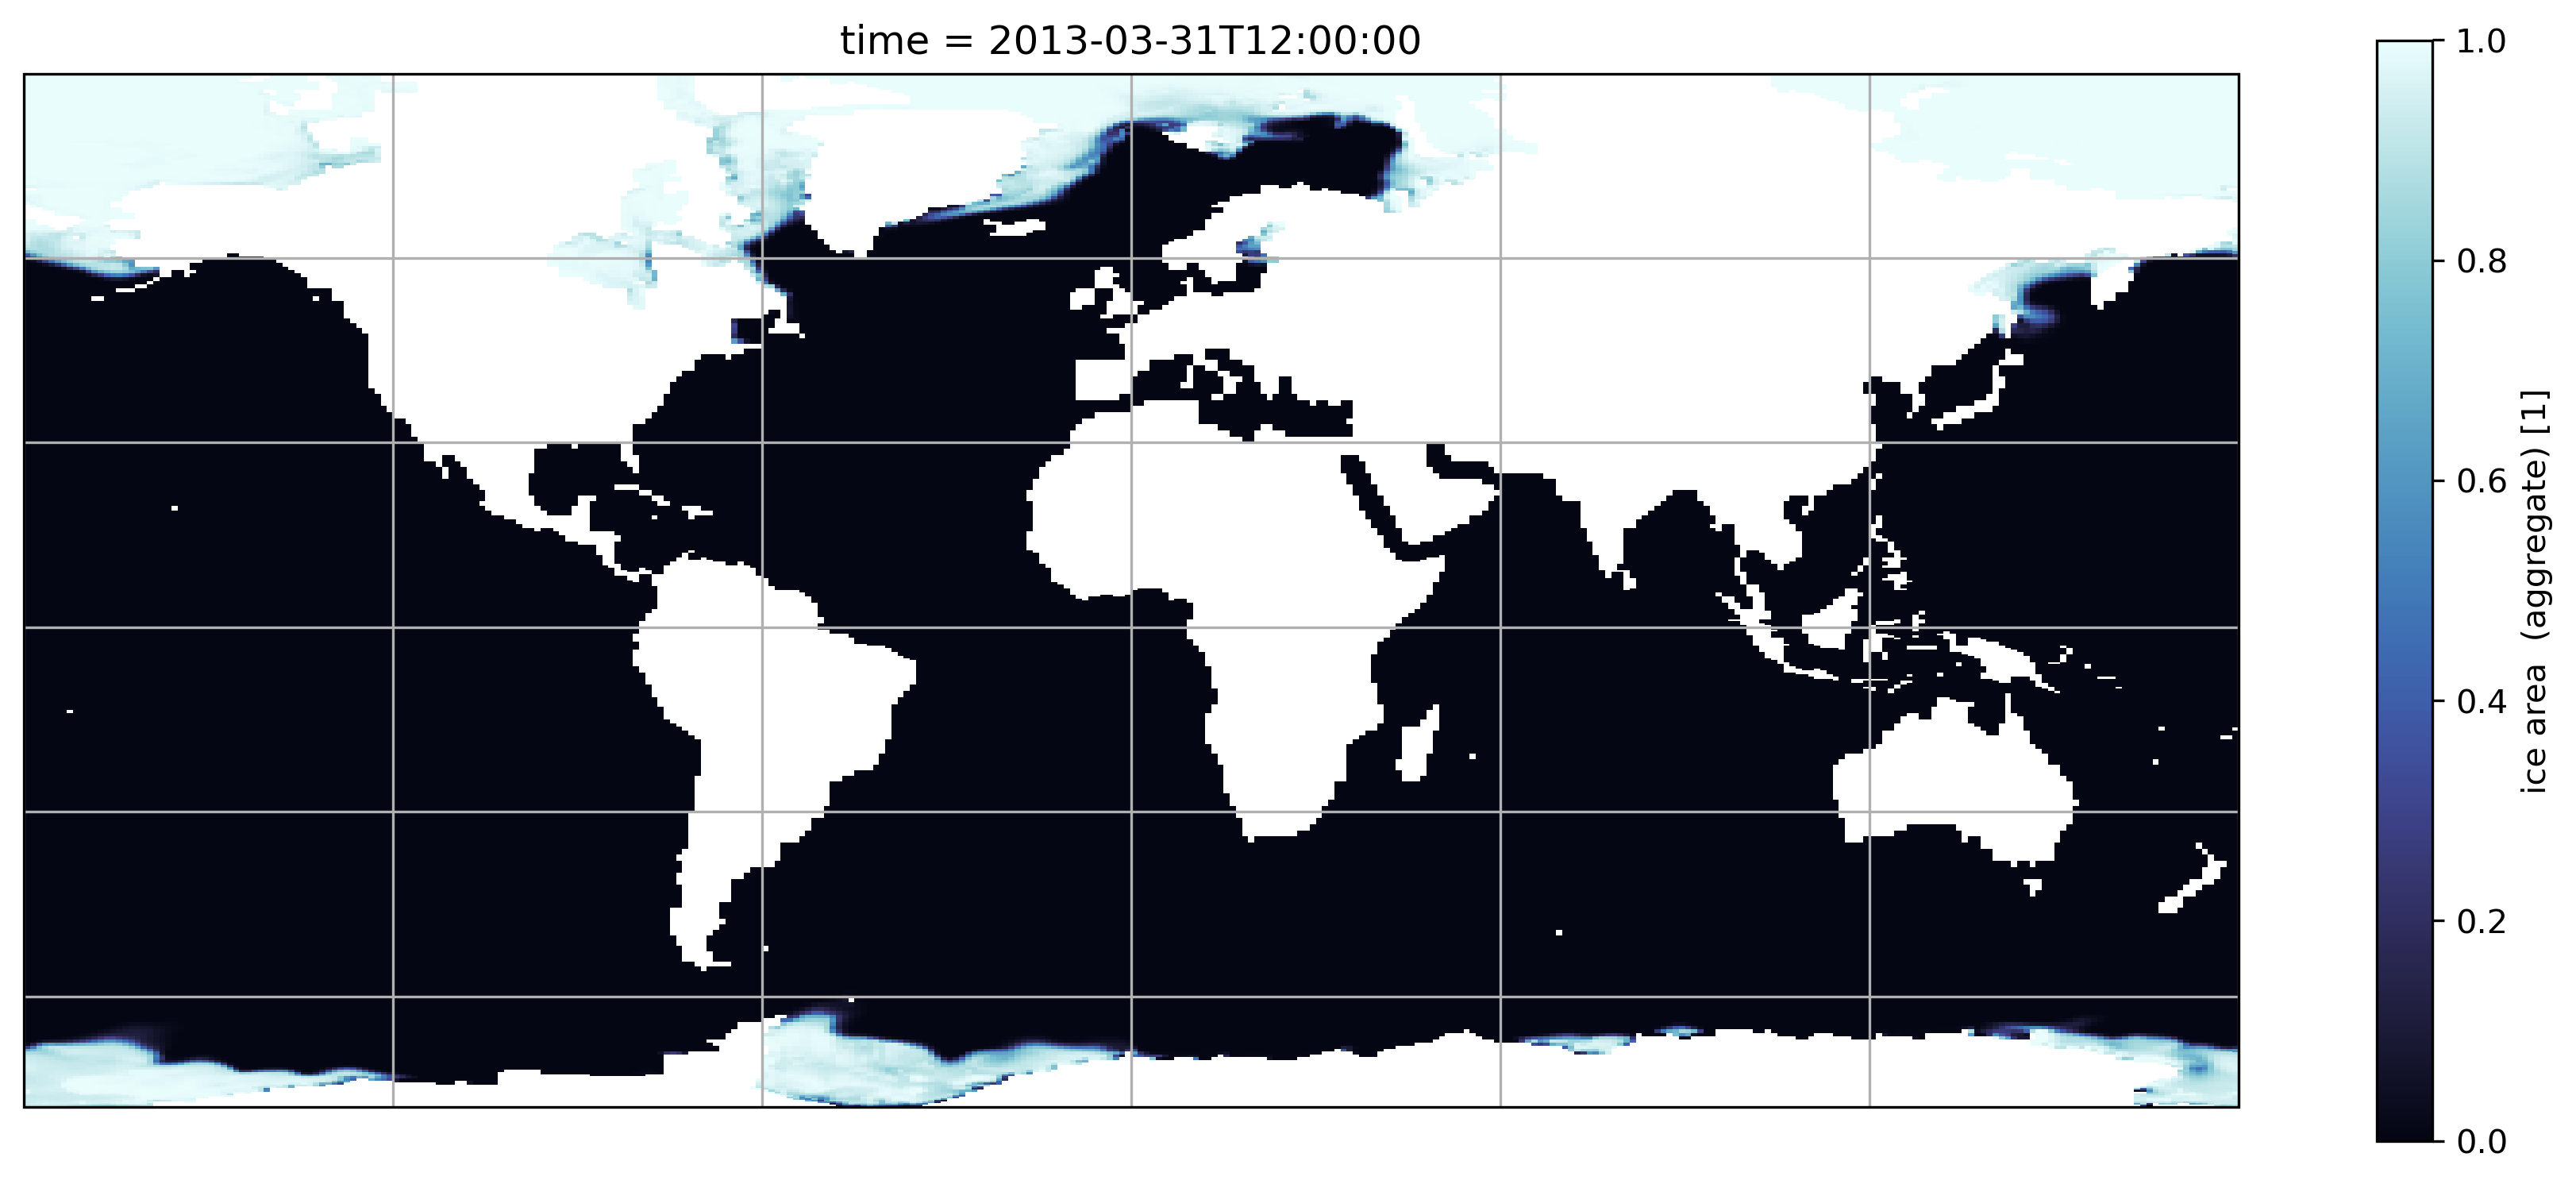

In [12]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

ds["aice"].isel(time=-1).plot(ax=ax, transform=proj, cmap=cmo.ice)
# ax.coastlines()
_ = ax.gridlines()
# ax.set_extent([-180, 180, -90, -50], crs=proj)

#### Fixing the plot axes

Notice that the white land-masked regions are distorted away from the coastlines in the Arctic in the above plot. This is because a tripolar grid is used, so the grid lines are not zonal and meridional north of 65N, and consequently the nominal 1D coordinates `xh` and `yh` are incorrect. To fix this we need to use 2d coordinates `geolon` and `geolat`.

We can get these coorindates from the intake-esm datastore. However, note that `geolon` and `geolat` contain NaNs in regions where processors were masked over land. Below we replace these NaNs with zeros so that the coordinates can be used for plotting.

In [13]:
# datastore.search(variable=["geolat", "geolon"]).unique()['file_id']

In [14]:
ds

<xarray.Dataset> Size: 113GB
Dimensions:     (time: 1186, nj: 300, ni: 360, nf: 12, nc: 5)
Coordinates: (12/14)
  * time        (time) datetime64[ns] 9kB 2010-01-01T12:00:00 ... 2013-03-31T...
    NCAT        (nc) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    TLON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    TLAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ...          ...
    ELON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ELAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
  * ni          (ni) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
  * nj          (nj) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
    geolon      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 79.96 79.97 79.99
    geolat      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 66.04 65.63 65.21
Dimensions without coordinates: nf, nc
Data variables:
    fsdrad      (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    aice        (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    afsd        (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_wave  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    afsdn       (time, nc, nf, nj, ni) float64 61GB dask.array<chunksize=(11, 1, 4, 300, 360), meta=np.ndarray>
    dafsd_weld  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_newi  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    NFSD        (nf) float64 96B 2.688 9.798 21.67 40.73 ... 506.2 668.2 850.5
    tarea       (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    HTE         (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/19)
    title:                                    access-om3
    contents:                                 Diagnostic and Prognostic Varia...
    source:                                   CICE Sea Ice Model, unknown_ver...
    time_period_freq:                         day_1
    time_axis_position:                       middle
    Conventions:                              CF-1.8
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,time: mean,time: mean,t...
    intake_esm_attrs:variable_units:          days since 2010-01-01 00:00:00,...
    intake_esm_attrs:realm:                   seaIce
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   access_om3_cice_1day_mean_XXXX_...

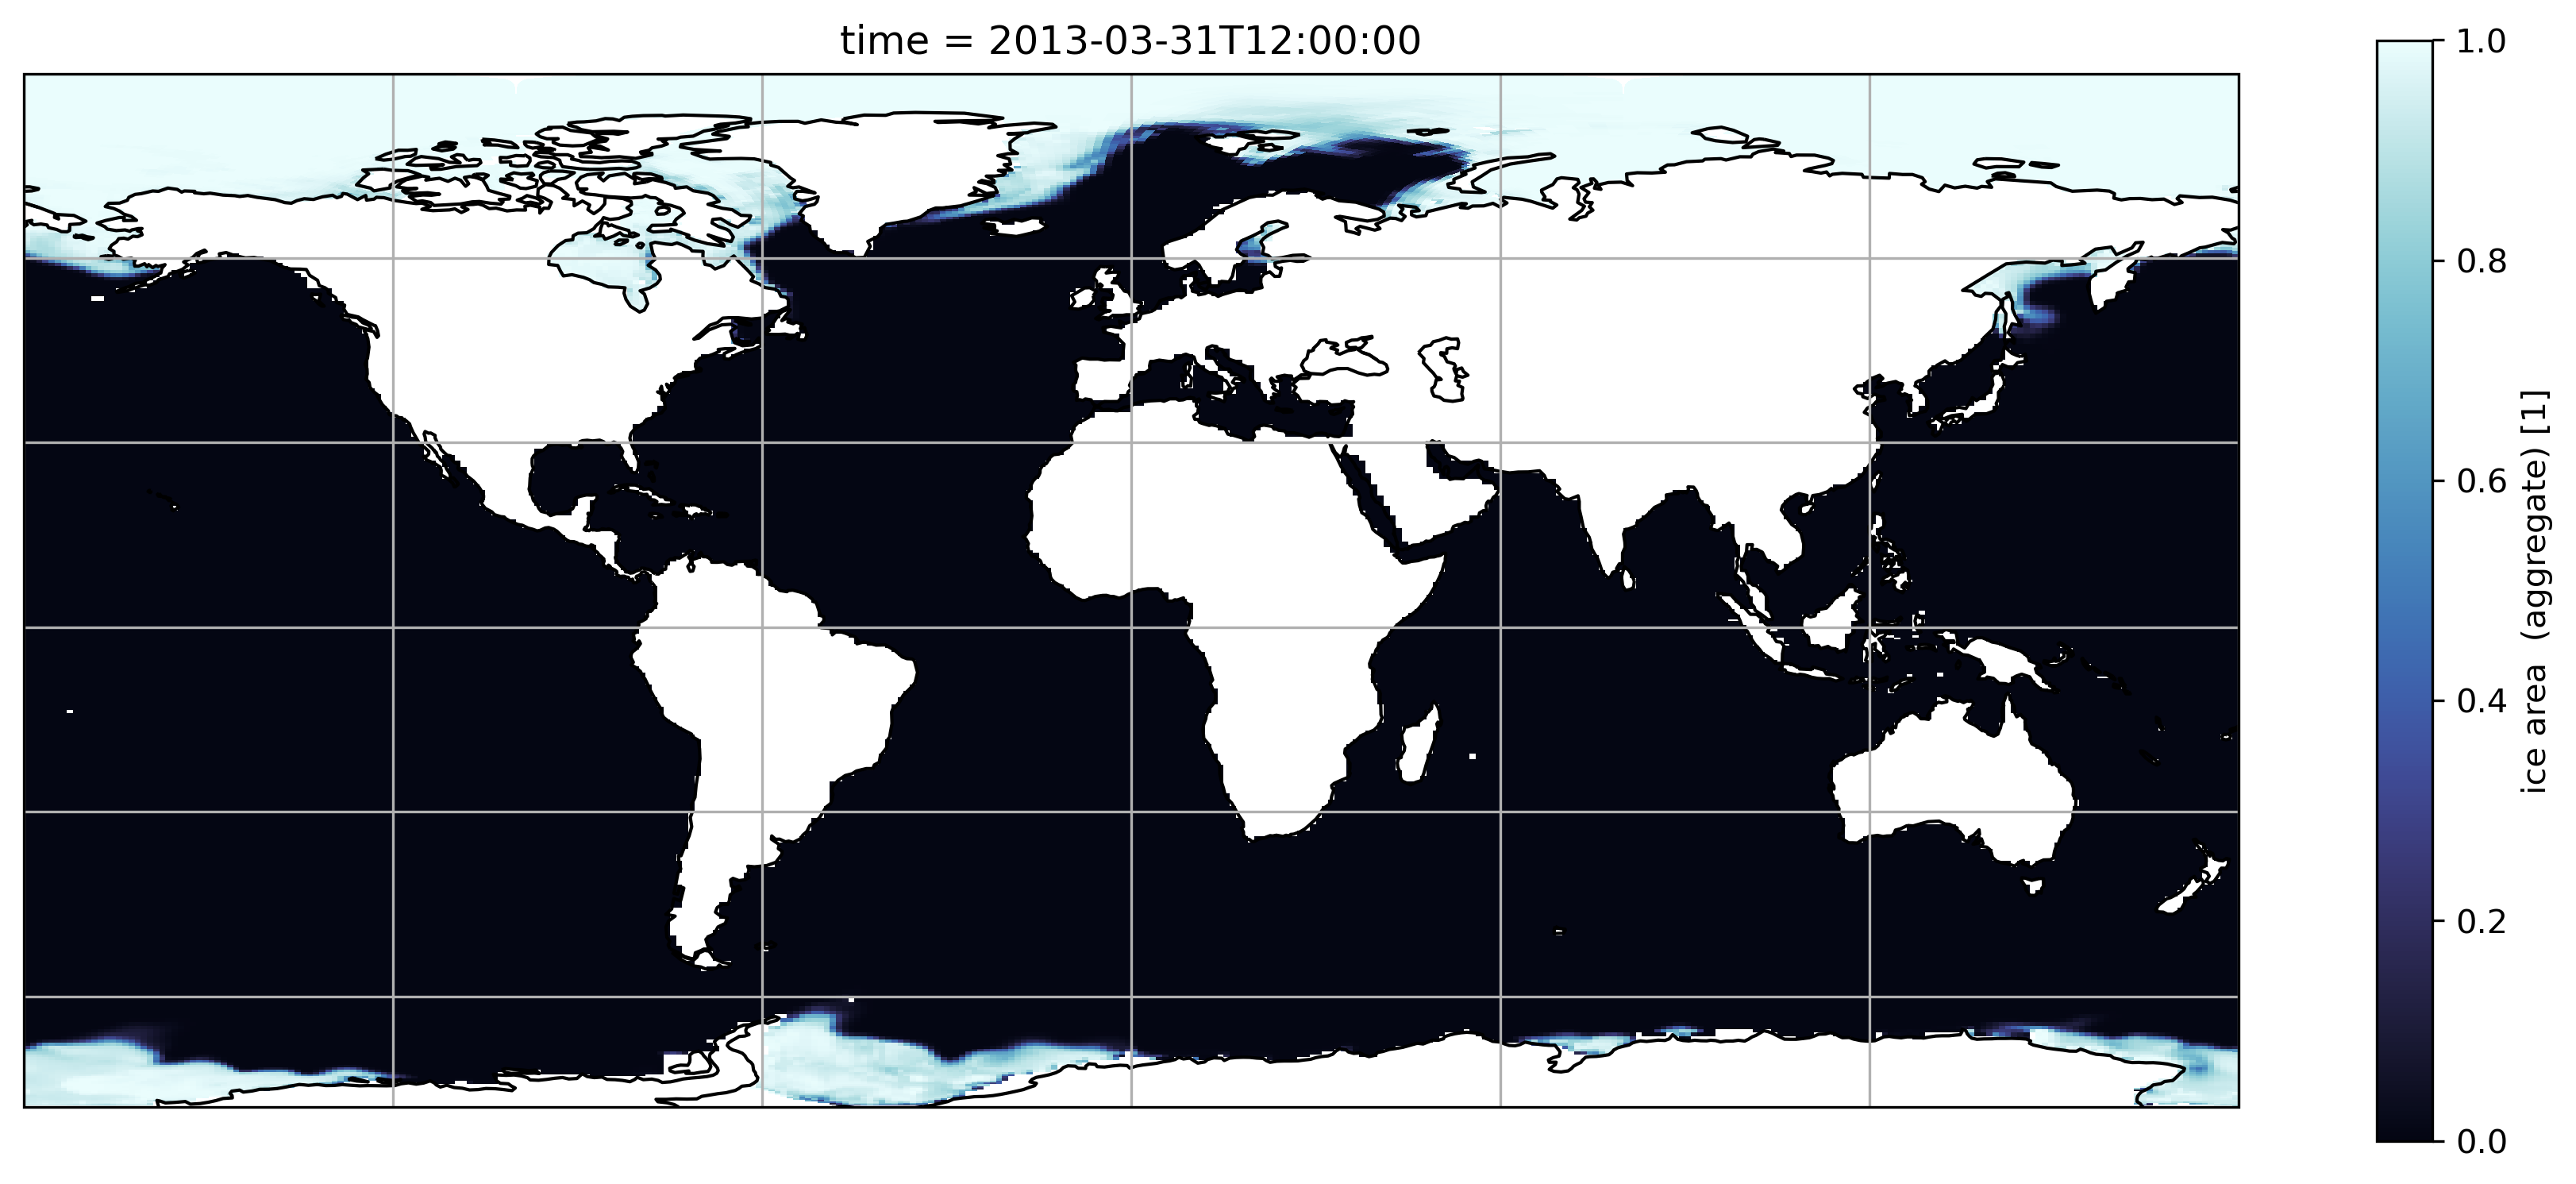

In [15]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

ds["aice"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat", cmap=cmo.ice)

ax.coastlines()
_ = ax.gridlines()
# plt.savefig(plotfolder+'exampleout.png')

In [16]:
ds_sh = ds.where((ds['aice'] > 0.15) & (ds['TLAT'] < 0))
ds_sh

<xarray.Dataset> Size: 127GB
Dimensions:     (time: 1186, nj: 300, ni: 360, nf: 12, nc: 5)
Coordinates: (12/14)
  * time        (time) datetime64[ns] 9kB 2010-01-01T12:00:00 ... 2013-03-31T...
    NCAT        (nc) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    TLON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    TLAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ULAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ...          ...
    ELON        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
    ELAT        (nj, ni) float64 864kB nan nan nan nan nan ... nan nan nan nan
  * ni          (ni) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
  * nj          (nj) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
    geolon      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 79.96 79.97 79.99
    geolat      (nj, ni) float64 864kB 0.0 0.0 0.0 0.0 ... 66.04 65.63 65.21
Dimensions without coordinates: nf, nc
Data variables:
    fsdrad      (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    aice        (time, nj, ni) float64 1GB dask.array<chunksize=(16, 300, 360), meta=np.ndarray>
    afsd        (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_wave  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    afsdn       (time, nc, nf, nj, ni) float64 61GB dask.array<chunksize=(11, 1, 4, 300, 360), meta=np.ndarray>
    dafsd_weld  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    dafsd_newi  (time, nf, nj, ni) float64 12GB dask.array<chunksize=(11, 4, 300, 360), meta=np.ndarray>
    NFSD        (nf, time, nj, ni) float64 12GB dask.array<chunksize=(12, 16, 300, 360), meta=np.ndarray>
    tarea       (nj, ni, time) float64 1GB dask.array<chunksize=(300, 360, 16), meta=np.ndarray>
    HTE         (nj, ni, time) float64 1GB dask.array<chunksize=(300, 360, 16), meta=np.ndarray>
Attributes: (12/19)
    title:                                    access-om3
    contents:                                 Diagnostic and Prognostic Varia...
    source:                                   CICE Sea Ice Model, unknown_ver...
    time_period_freq:                         day_1
    time_axis_position:                       middle
    Conventions:                              CF-1.8
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,time: mean,time: mean,t...
    intake_esm_attrs:variable_units:          days since 2010-01-01 00:00:00,...
    intake_esm_attrs:realm:                   seaIce
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   access_om3_cice_1day_mean_XXXX_...

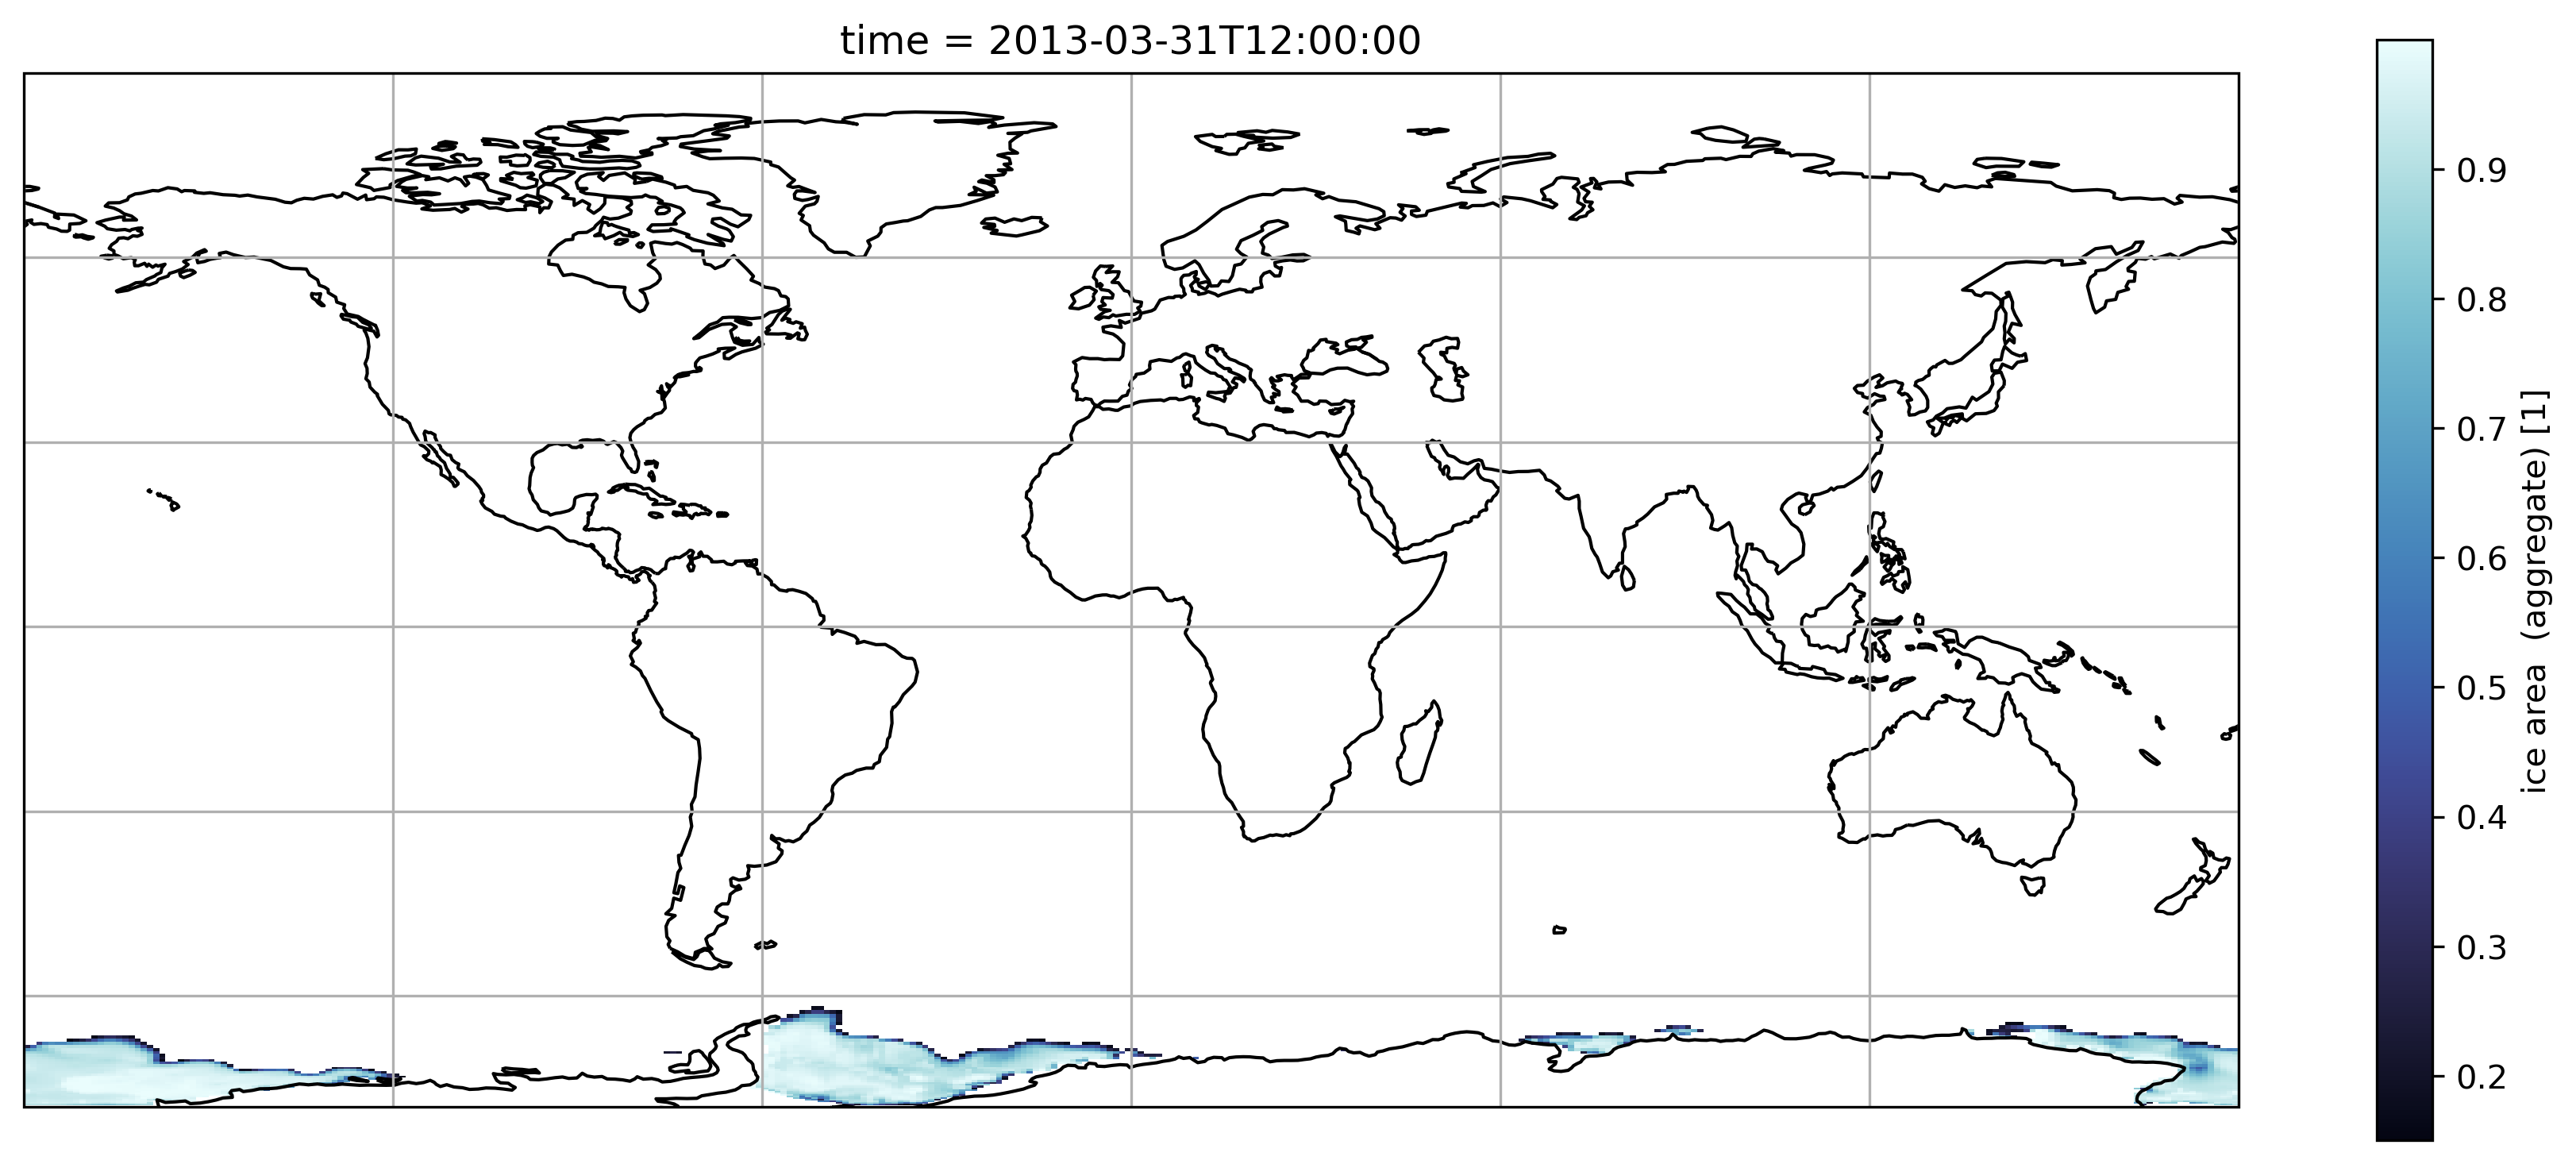

In [17]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

ds_sh["aice"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat", cmap=cmo.ice)

ax.coastlines()
_ = ax.gridlines()
# plt.savefig(plotfolder+'exampleout.png')

In [18]:
lat = ds['TLAT']

# Mask latitudes the same way
lat_masked = lat.where(~np.isnan(ds_sh['aice']), other=-90)

# Get index of northernmost point along nj (latitude dimension)
j_north = lat_masked.argmax(dim='nj').compute()

In [19]:
aice_edge = ds_sh['aice'].isel(nj=j_north)
lat_edge  = lat.isel(nj=j_north)
lon_edge  = ds['TLON'].isel(nj=j_north)

In [20]:
# j_north - 1

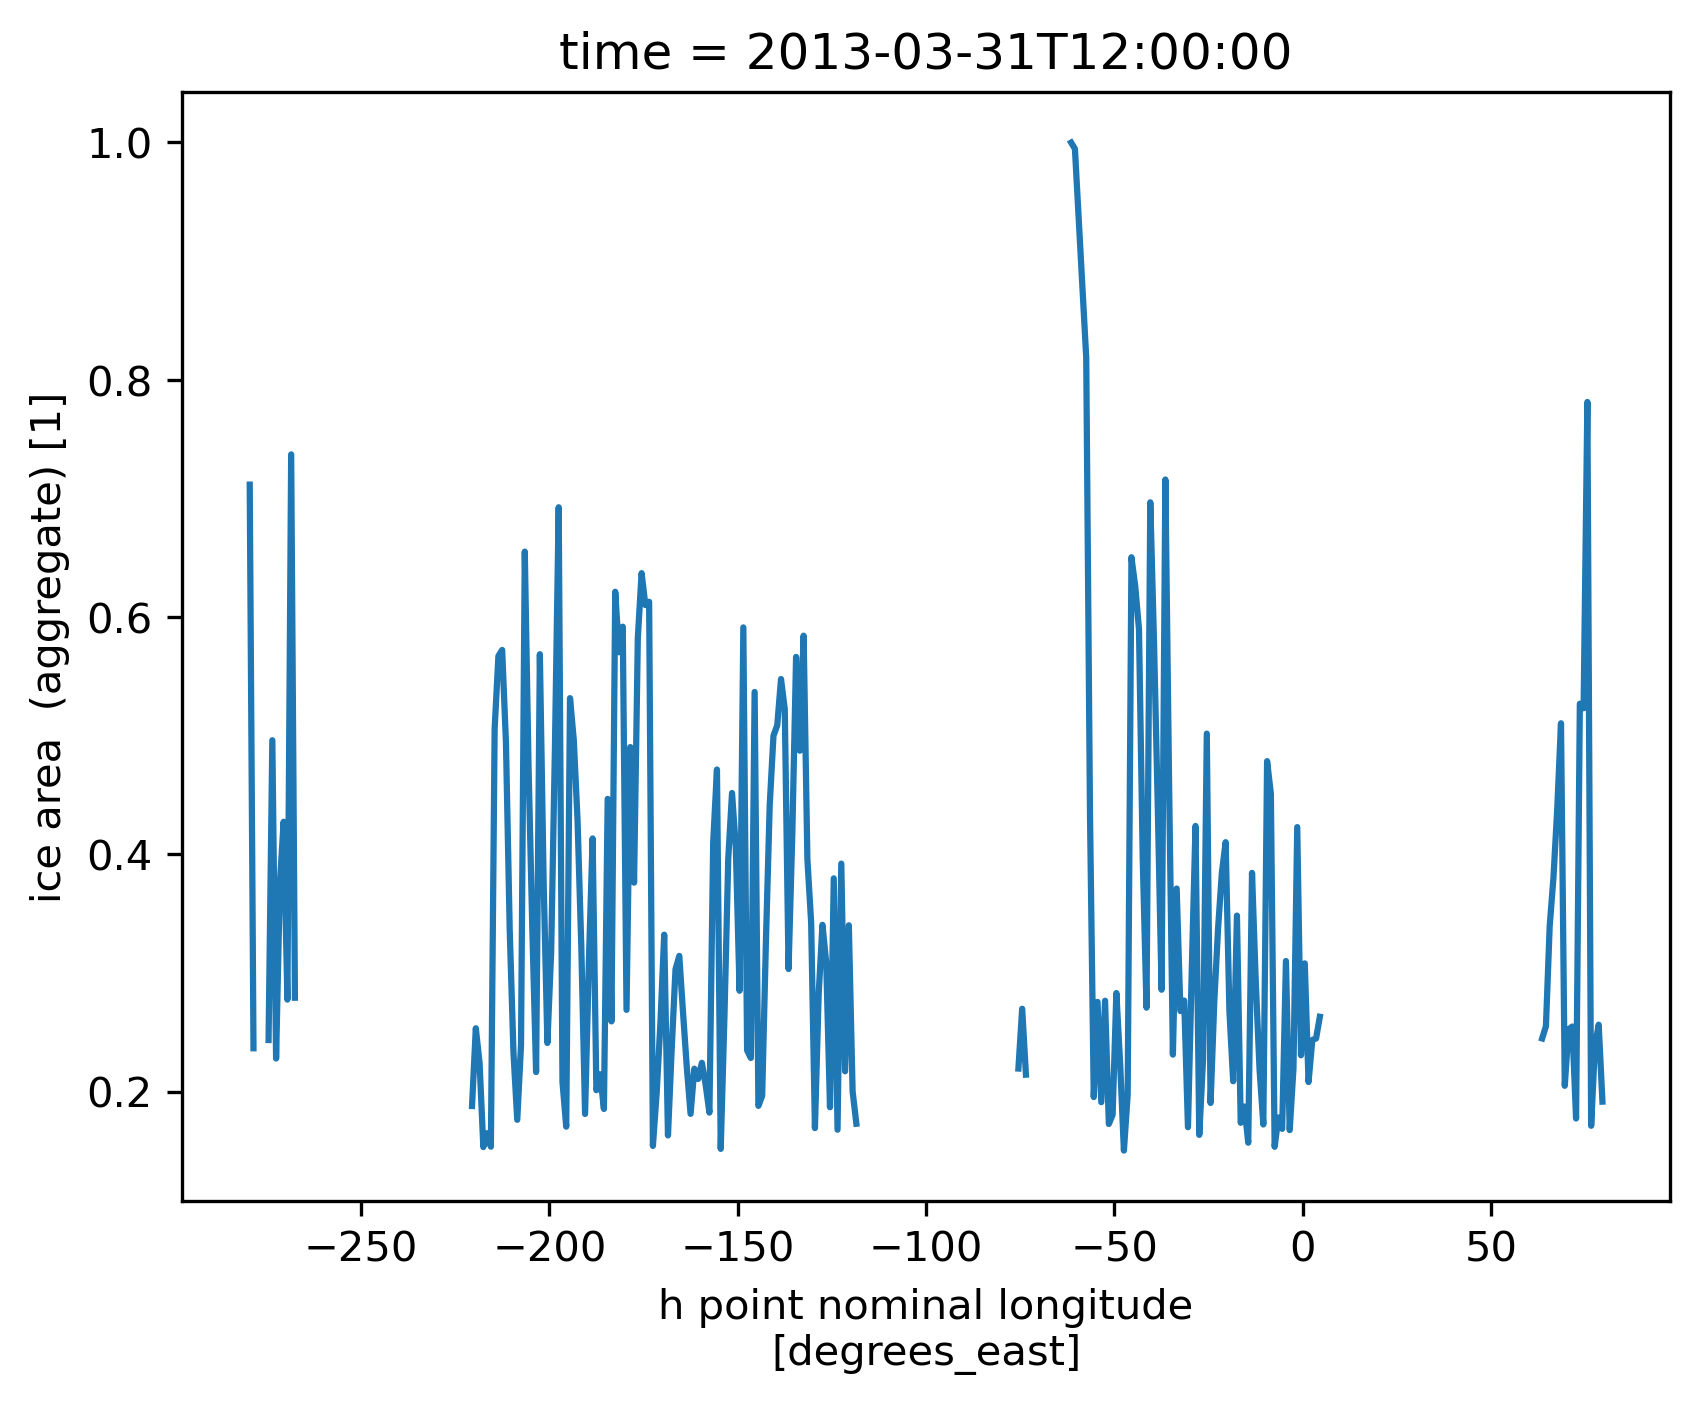

In [21]:
aice_edge.isel(time=-1).plot()

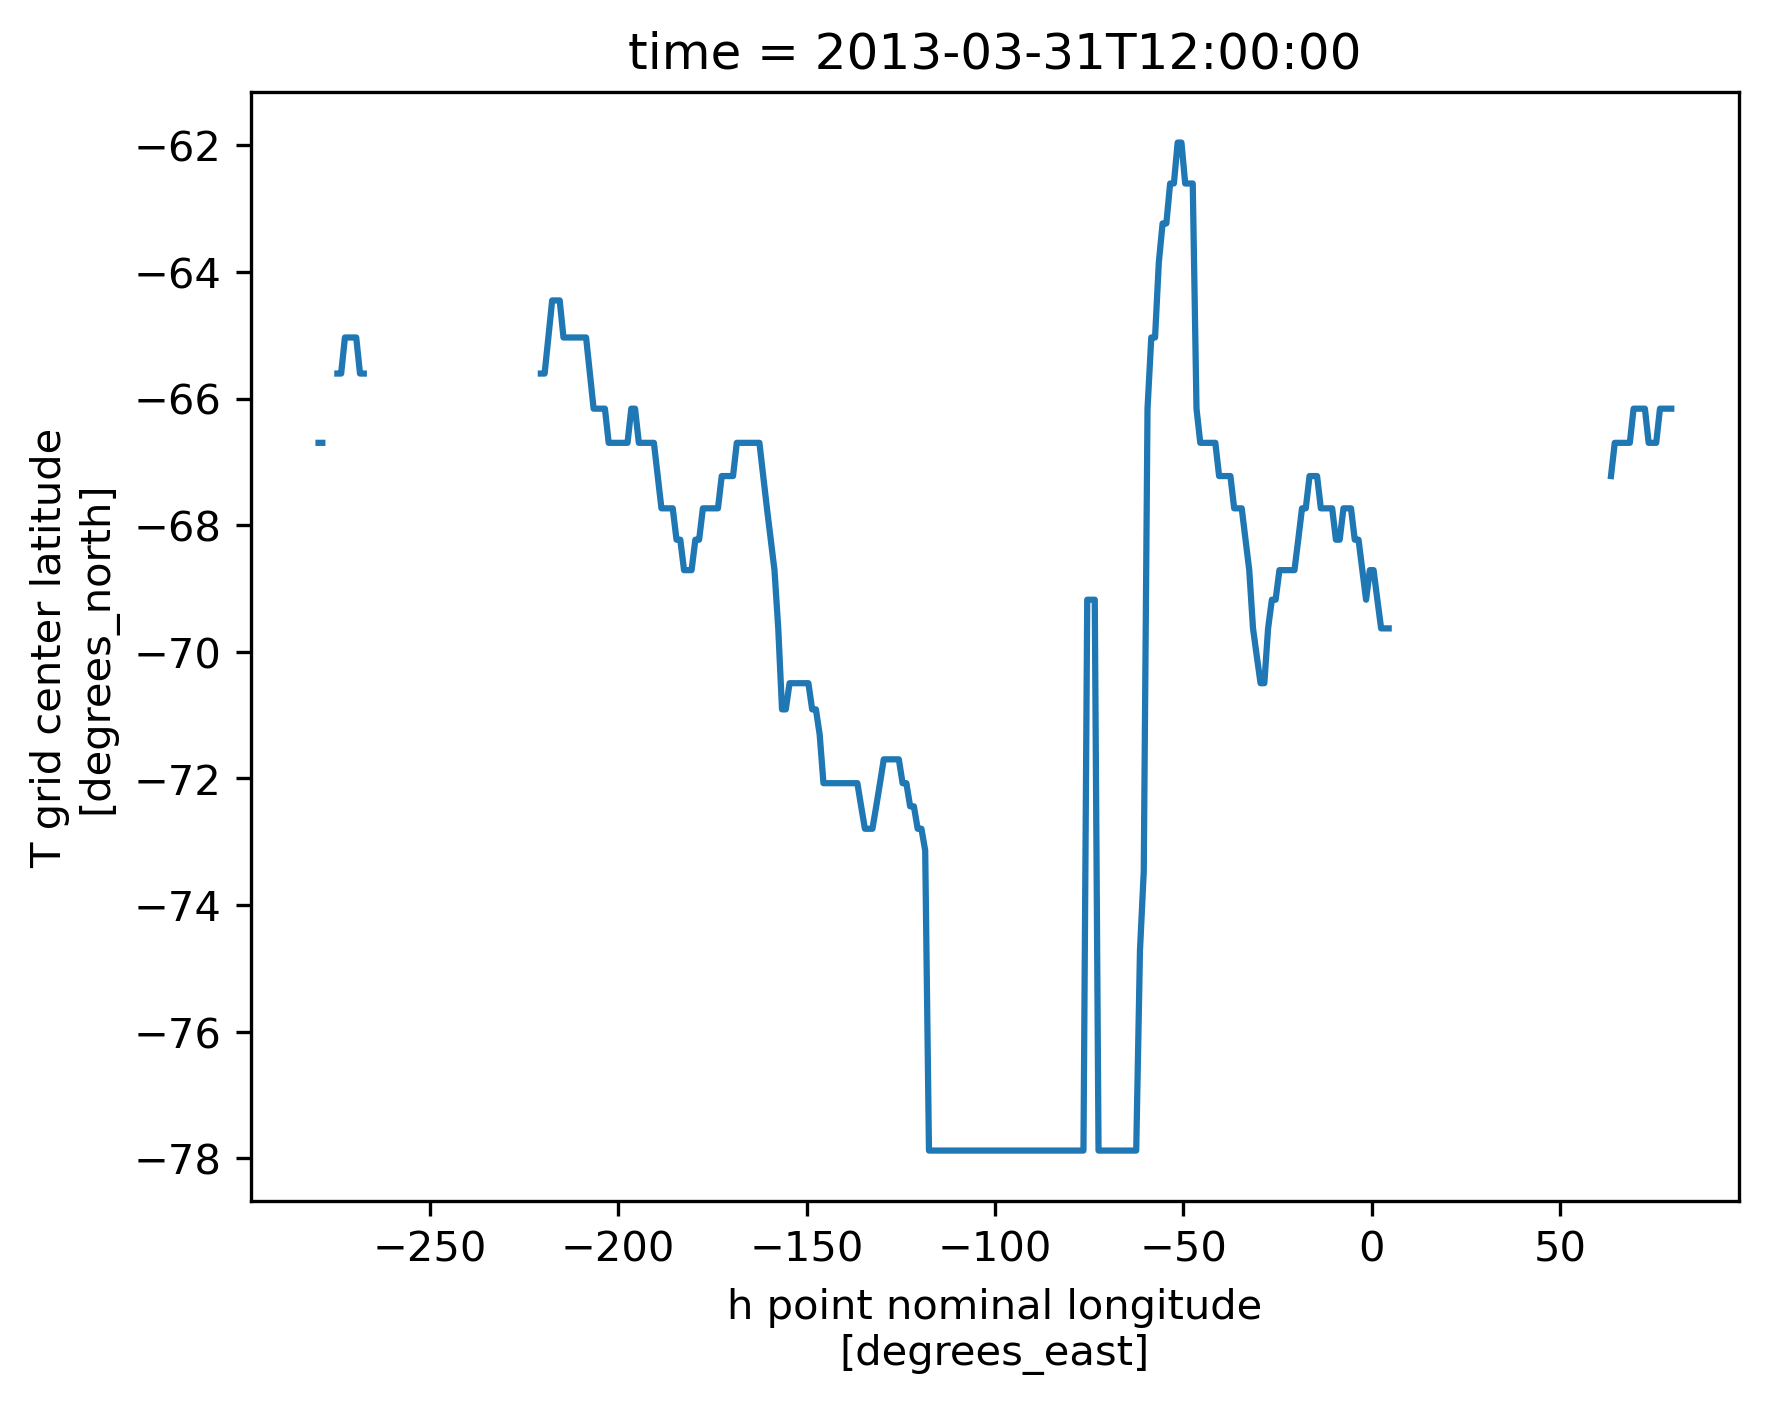

In [22]:
lat_edge.isel(time=-1).plot()

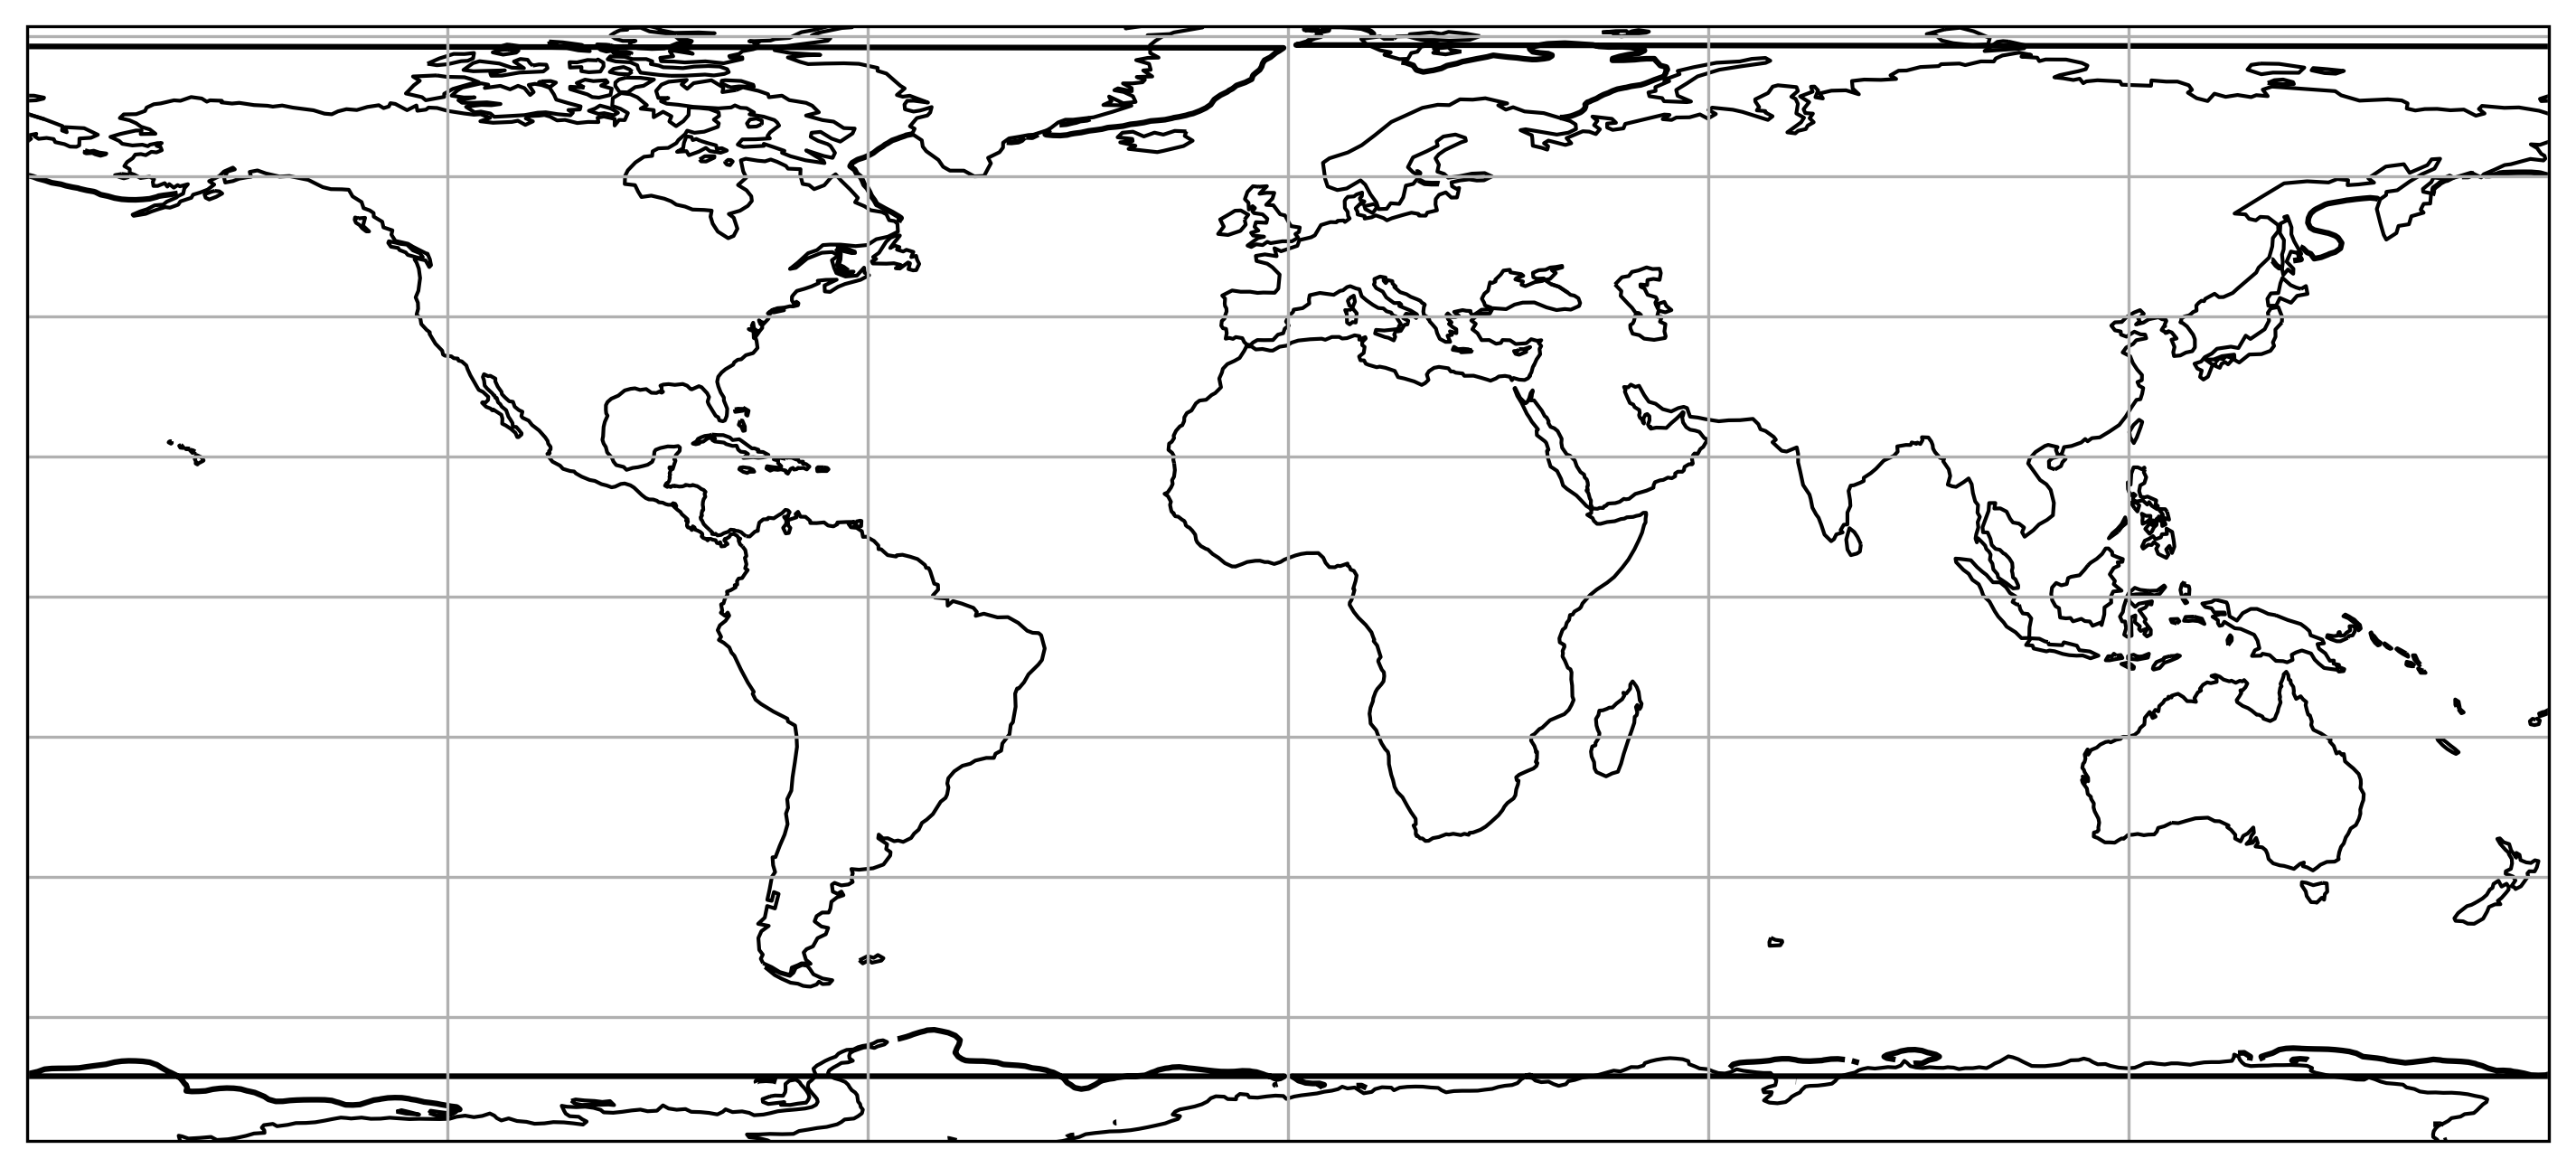

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=proj))

cs = ax.contour(
    ds['TLON'],
    ds['TLAT'],
    ds['aice'].isel(time=-1),
    levels=[0.15],
    transform=ccrs.PlateCarree(),
    colors='k'
)

ax.coastlines()
ax.gridlines()

plt.show()

In [24]:
afsd_edge = ds_sh['afsd'].isel(nj=j_north)
afsd_edge_m1 = ds_sh['afsd'].isel(nj=j_north-1)
afsd_edge_m2 = ds_sh['afsd'].isel(nj=j_north-2)
afsd_edge_m3 = ds_sh['afsd'].isel(nj=j_north-3)

In [25]:
BinWidths, BinLeft, BinRight = ciceBinWidths(ds['NFSD'])
bin_centers = 0.5 * (BinLeft + BinRight)
BinLeft_d  = 2 * BinLeft
BinRight_d = 2 * BinRight
bin_centers_d = 0.5 * (BinLeft_d + BinRight_d)
BinWidths_d = BinWidths * 2

In [26]:
j_offsets = [0, -1, -2, -3, -4, -5]
labels = ["Ice edge", "Ice edge (-1)", "Ice edge (-2)", "Ice edge (-3)", "Ice edge (-4)", "Ice edge (-5)"]
time_idx = -1
ds_sh['time'].isel(time=time_idx).values

numpy.datetime64('2013-03-31T12:00:00.000000000')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 11.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/cli

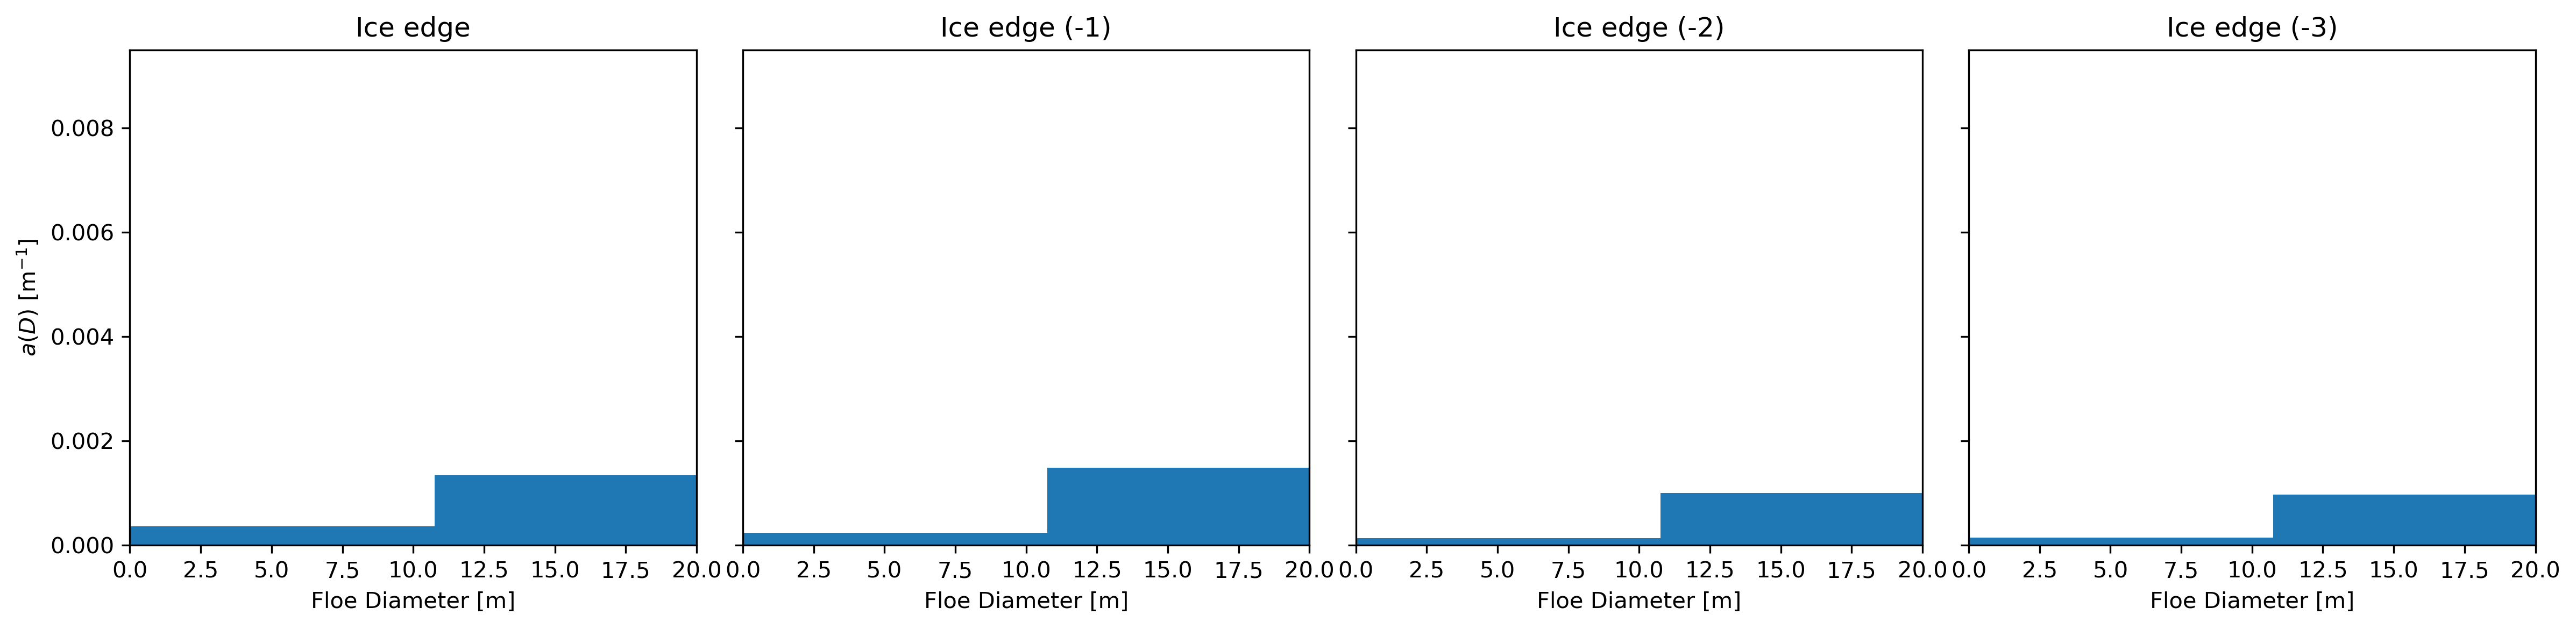

In [27]:
bin_centers_d = 0.5 * (BinLeft_d + BinRight_d)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, j_off, label in zip(axes, j_offsets, labels):

    afsd = ds_sh['afsd'].isel(nj=j_north + j_off).isel(time=time_idx).mean(dim='ni').load()

    ax.bar(
        bin_centers_d,
        afsd,
        width=BinWidths_d,
        align='center'
    )

    ax.set_title(label)
    ax.set_xlim(0, 20)
    ax.set_xlabel("Floe Diameter [m]")

axes[0].set_ylabel("$a(D)$ [m$^{-1}$]")
plt.tight_layout()
plt.show()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 11.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/cli

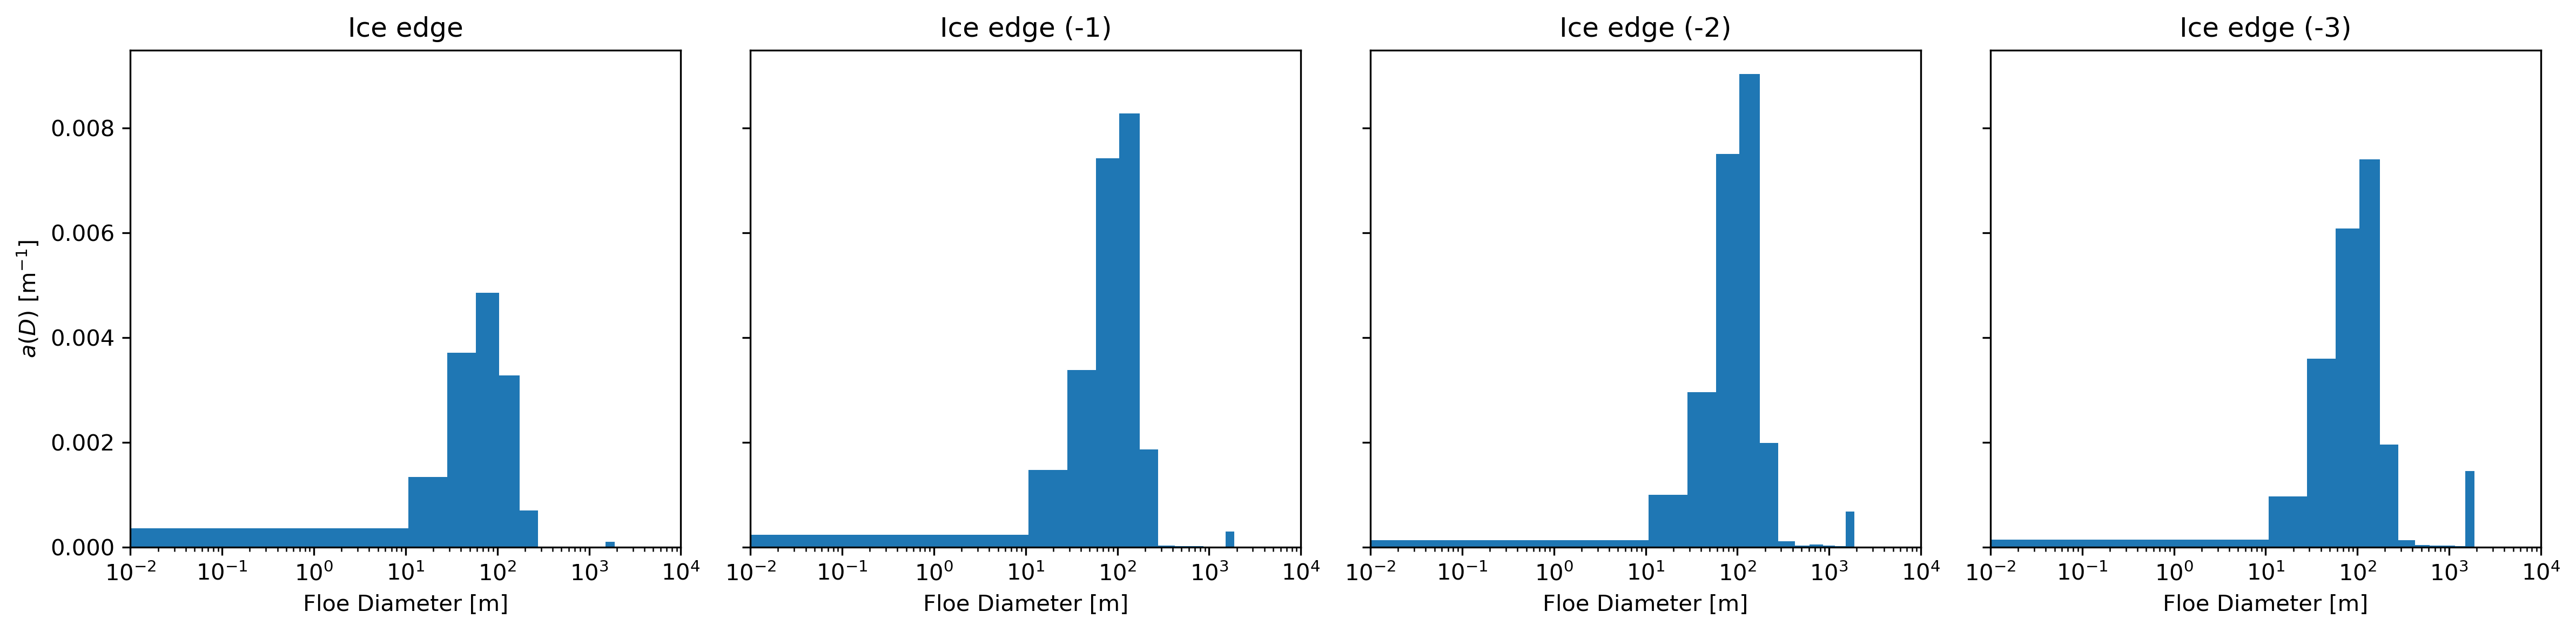

In [28]:
bin_centers_d = 0.5 * (BinLeft_d + BinRight_d)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, j_off, label in zip(axes, j_offsets, labels):

    afsd = ds_sh['afsd'].isel(nj=j_north + j_off).isel(time=time_idx).mean(dim='ni').load()

    ax.bar(
        bin_centers_d,
        afsd,
        width=BinWidths_d,
        align='center'
    )

    ax.set_title(label)
    ax.set_xlim(1e-2, 1e4)
    ax.set_xscale('log')
    ax.set_xlabel("Floe Diameter [m]")

axes[0].set_ylabel("$a(D)$ [m$^{-1}$]")
plt.tight_layout()
plt.show()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 11.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/cli

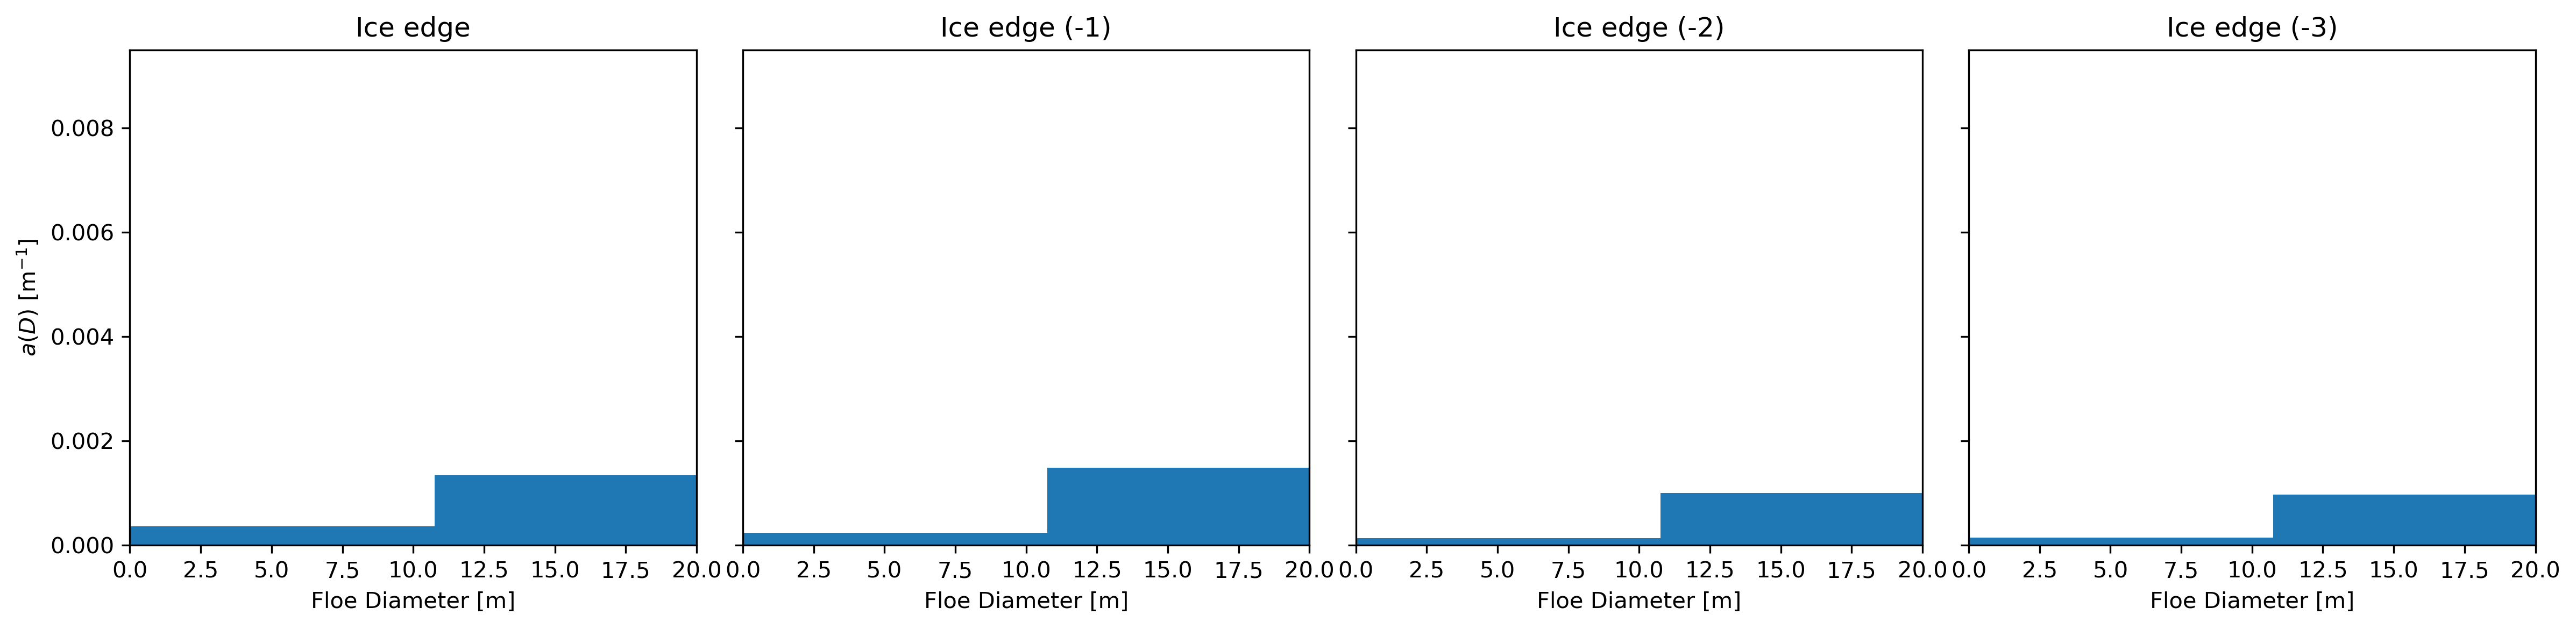

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, j_off, label in zip(axes, j_offsets, labels):

    afsd = ds_sh['afsd'].isel(nj=j_north + j_off).isel(time=time_idx).mean(dim='ni').load()

    pdf = afsd / afsd.sum()
    cdf = pdf.cumsum(dim='nf')

    cdf_vals = cdf.values
    bins = bin_centers_d

    q25 = np.interp(0.25, cdf_vals, bins)
    q75 = np.interp(0.75, cdf_vals, bins)

    ax.bar(bin_centers_d, afsd, width=BinWidths_d, align='center')
    ax.axvspan(q25, q75, color='tab:blue', alpha=0.3)

    ax.set_title(label)
    ax.set_xlim(0, 20)
    ax.set_xlabel("Floe Diameter [m]")
axes[0].set_ylabel("$a(D)$ [m$^{-1}$]")
plt.tight_layout()
plt.show()

In [31]:
# bin_centers_d

## Analysis of FSD

In [32]:
def integrateFloeSize(ds, var):
    puny = 1e-12
    tmp_var = var[0:-3]

    # Mask once
    ds_masked = ds.where(ds['aice'] > puny)

    # Get weights
    NFSD = xr.DataArray(ds.NFSD.values, dims=["nf"])

    # Weighted sum over nf
    int_var = (ds_masked[tmp_var] * NFSD).sum(dim="nf") / ds_masked["aice"]

    # Fill NaNs where aice is tiny (optional)
    int_var = int_var.fillna(0)

    # Assign to output dataset
    ds_out = ds.copy()
    ds_out[var] = int_var

    # Attributes
    parts = ds[tmp_var].attrs['long_name'].split(':')
    ds_out[var].attrs['long_name'] = parts[0][:-3] + 'rep. radius:' + parts[1]
    ds_out[f'{var}'].attrs['units'] = 'm/timestep'

    return ds_out
    
ds_sh['NFSD'] = ds_sh['NFSD'].mean(dim=['ni', 'nj', 'time'])
ds_sh = integrateFloeSize(ds_sh, 'dafsd_wave_ra')
ds_sh = integrateFloeSize(ds_sh, 'dafsd_weld_ra')
ds_sh = integrateFloeSize(ds_sh, 'dafsd_newi_ra')

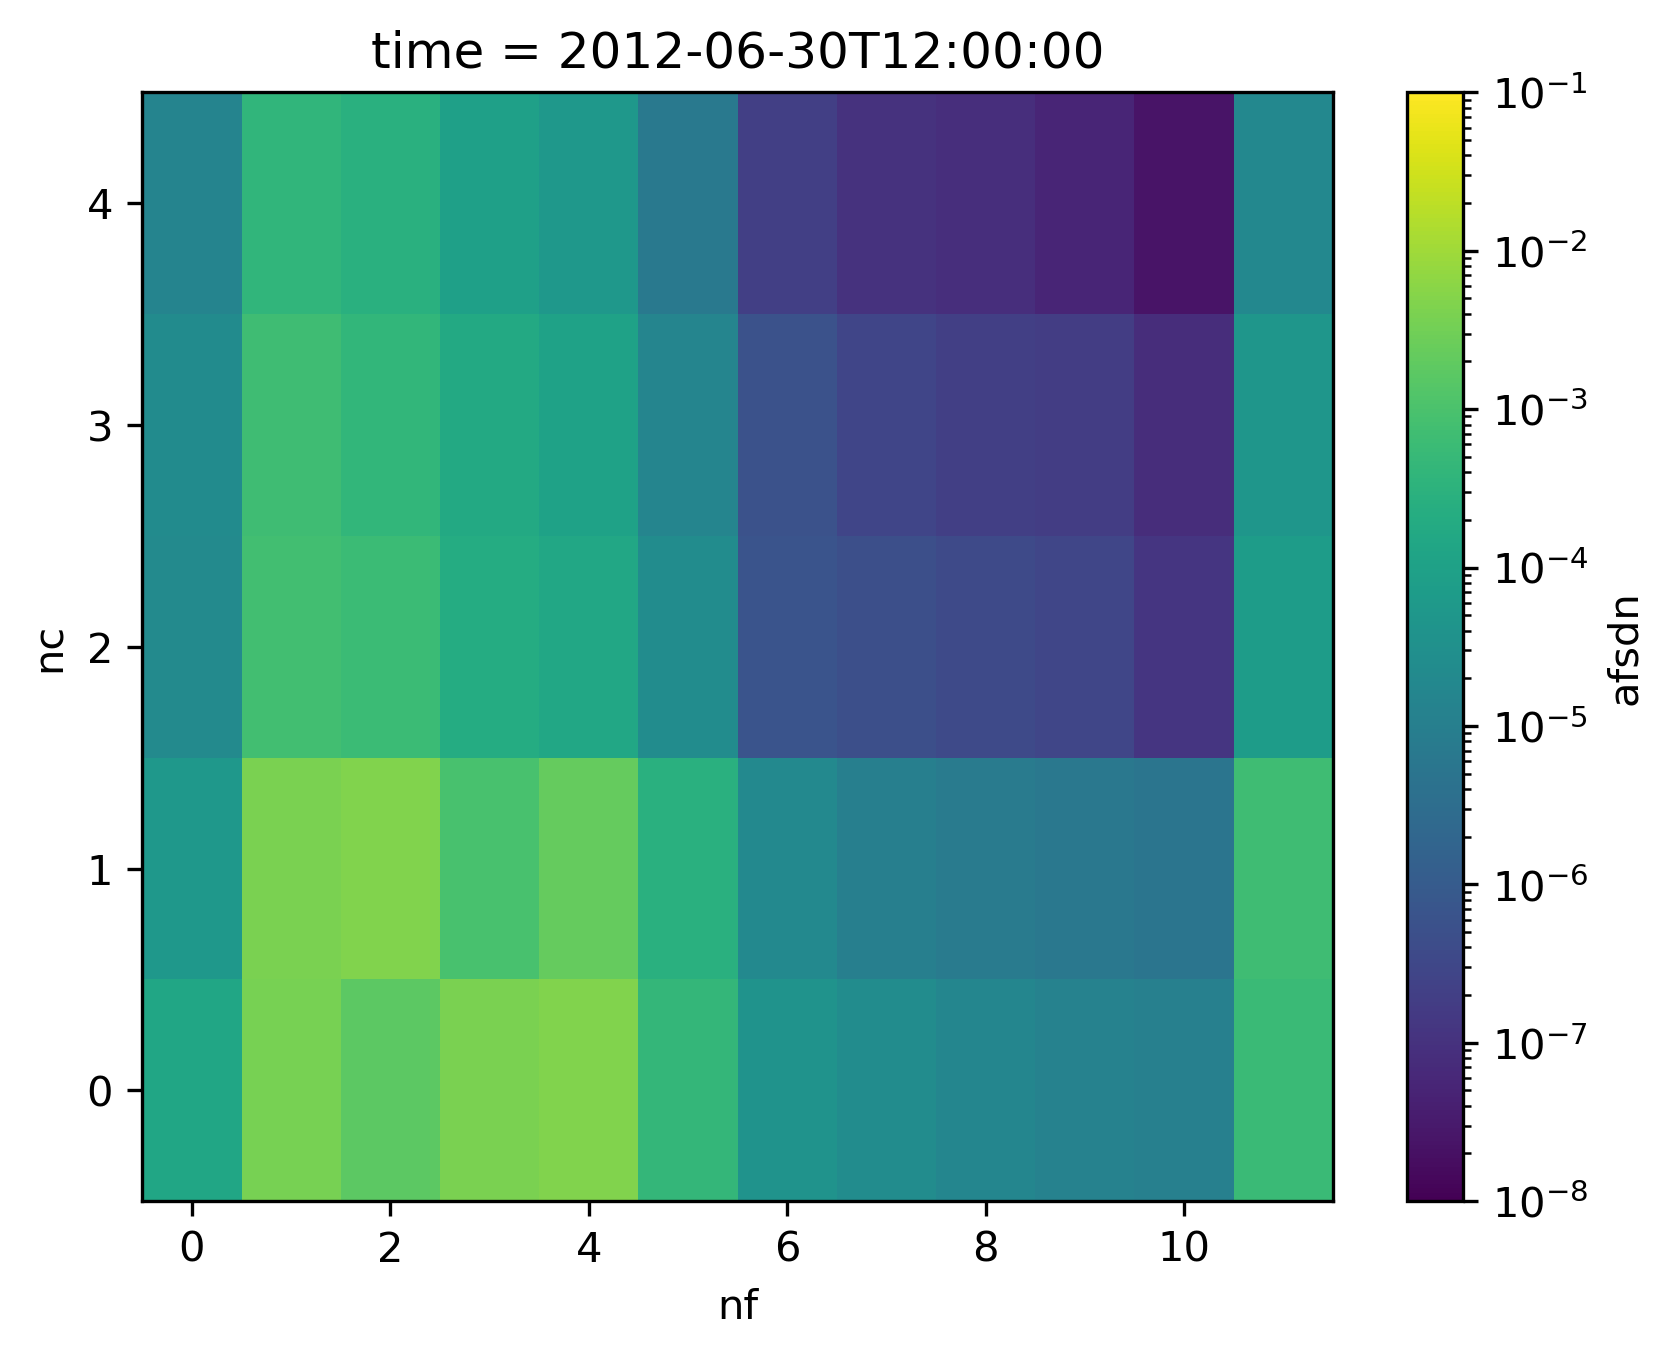

In [37]:
from matplotlib.colors import LogNorm
ds_sh['afsdn'].isel(time=-275).mean(dim=['ni', 'nj']).plot(norm=LogNorm(1e-8, 1e-1))

In [38]:
import numpy as np
from scipy.signal import savgol_filter, find_peaks

da = ds_sh['afsd'].isel(time=-1).mean(dim=['ni','nj'])
x = da['nf'].values
y = da.values
y_smooth = savgol_filter(y, window_length=7, polyorder=2)

peaks, _ = find_peaks(y_smooth)

In [39]:
from scipy.signal import find_peaks

# minima = peaks of the negative signal
mins, _ = find_peaks(-y_smooth)

In [40]:
import numpy as np
from scipy.signal import savgol_filter, find_peaks

da = ds_sh['afsd'].isel(time=-1).mean(dim=['ni','nj'])

y = da.values

# 1. Smooth
y_smooth = savgol_filter(y, window_length=7, polyorder=2)

# 2. Find peaks (modes)
peaks, _ = find_peaks(y_smooth)

# 3. Find minima (boundaries)
mins, _ = find_peaks(-y_smooth)

# 4. Build region boundaries
# include edges
bounds = np.concatenate(([0], mins, [len(y)]))

# 5. Compute bin widths
bin_width = np.gradient(da['nf'].values)

# 6. Loop over regions
mode_masses = []

for i in range(len(bounds)-1):
    start = bounds[i]
    end = bounds[i+1]

    region = slice(start, end)

    mass = np.sum(y[region] * bin_width[region])
    mode_masses.append(mass)

print("Mode masses:", mode_masses)

Mode masses: [0.01786035923795758, 0.0016595924612982597]


In [41]:
bounds

array([ 0,  8, 12])

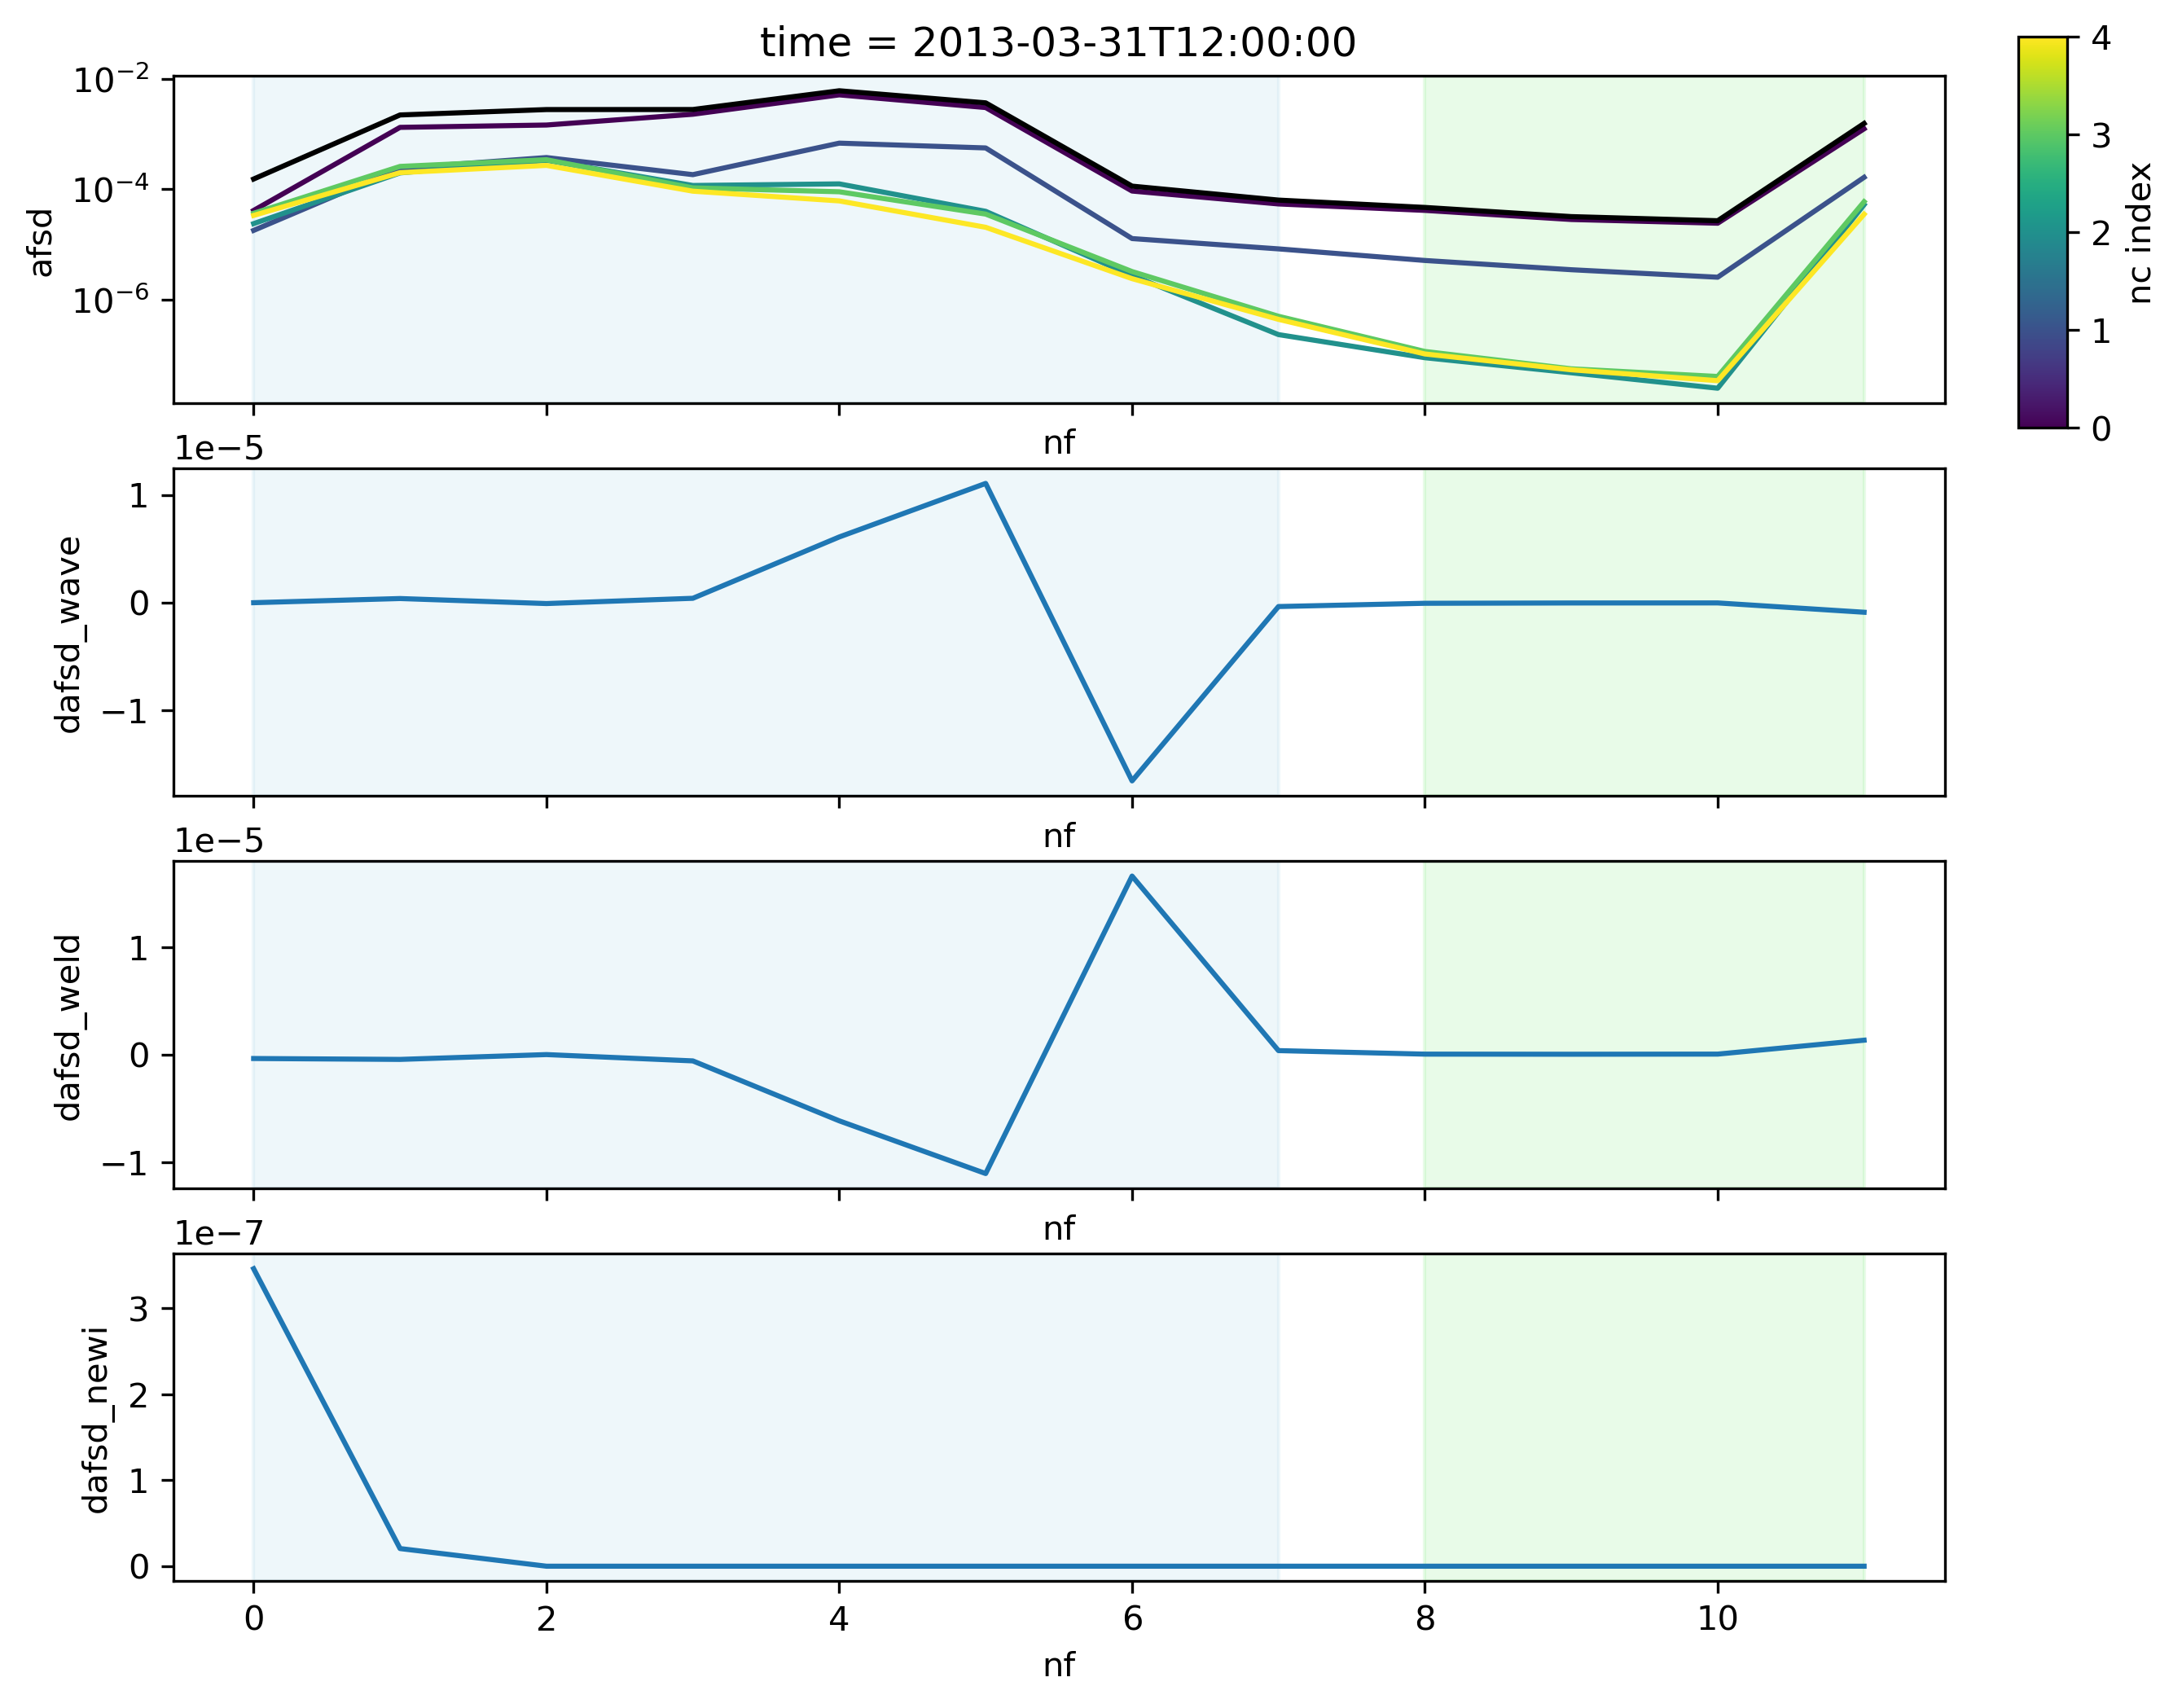

In [42]:
import matplotlib as mpl
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, sharey=False)
axes = axes.flatten()
fig.subplots_adjust(right=0.85)

da = ds_sh['afsdn'].isel(time=-1).mean(dim=['ni', 'nj'])

# Axis 0
n_lines = 5
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=n_lines-1)

for i in range(n_lines):
    color = cmap(norm(i))
    da.isel(nc=i).plot(ax=axes[0], color=color)

cax = fig.add_axes([0.88, 0.7, 0.02, 0.2]) 
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for matplotlib quirk
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('nc index')

ds_sh['afsd'].isel(time=-1).mean(dim=['ni', 'nj']).plot(ax=axes[0], color='k')

axes[0].set_yscale('log')

# Axis 1
ds_sh['dafsd_wave'].isel(time=-1).mean(dim=['ni', 'nj']).plot(ax=axes[1])

# Axis 2
ds_sh['dafsd_weld'].isel(time=-1).mean(dim=['ni', 'nj']).plot(ax=axes[2])

# Axis 3
ds_sh['dafsd_newi'].isel(time=-1).mean(dim=['ni', 'nj']).plot(ax=axes[3])

# Axis 4

colors = ['lightblue', 'lightgreen', 'lightcoral']  # one per mode

for i in range(len(bounds)-1):
    x0 = x[bounds[i]]
    x1 = x[bounds[i+1]-1]

    for ax in axes:
        ax.axvspan(x0, x1, color=colors[i], alpha=0.2)

for ax in axes[1:]:
    ax.set_title('')

# plt.tight_layout()
plt.show()

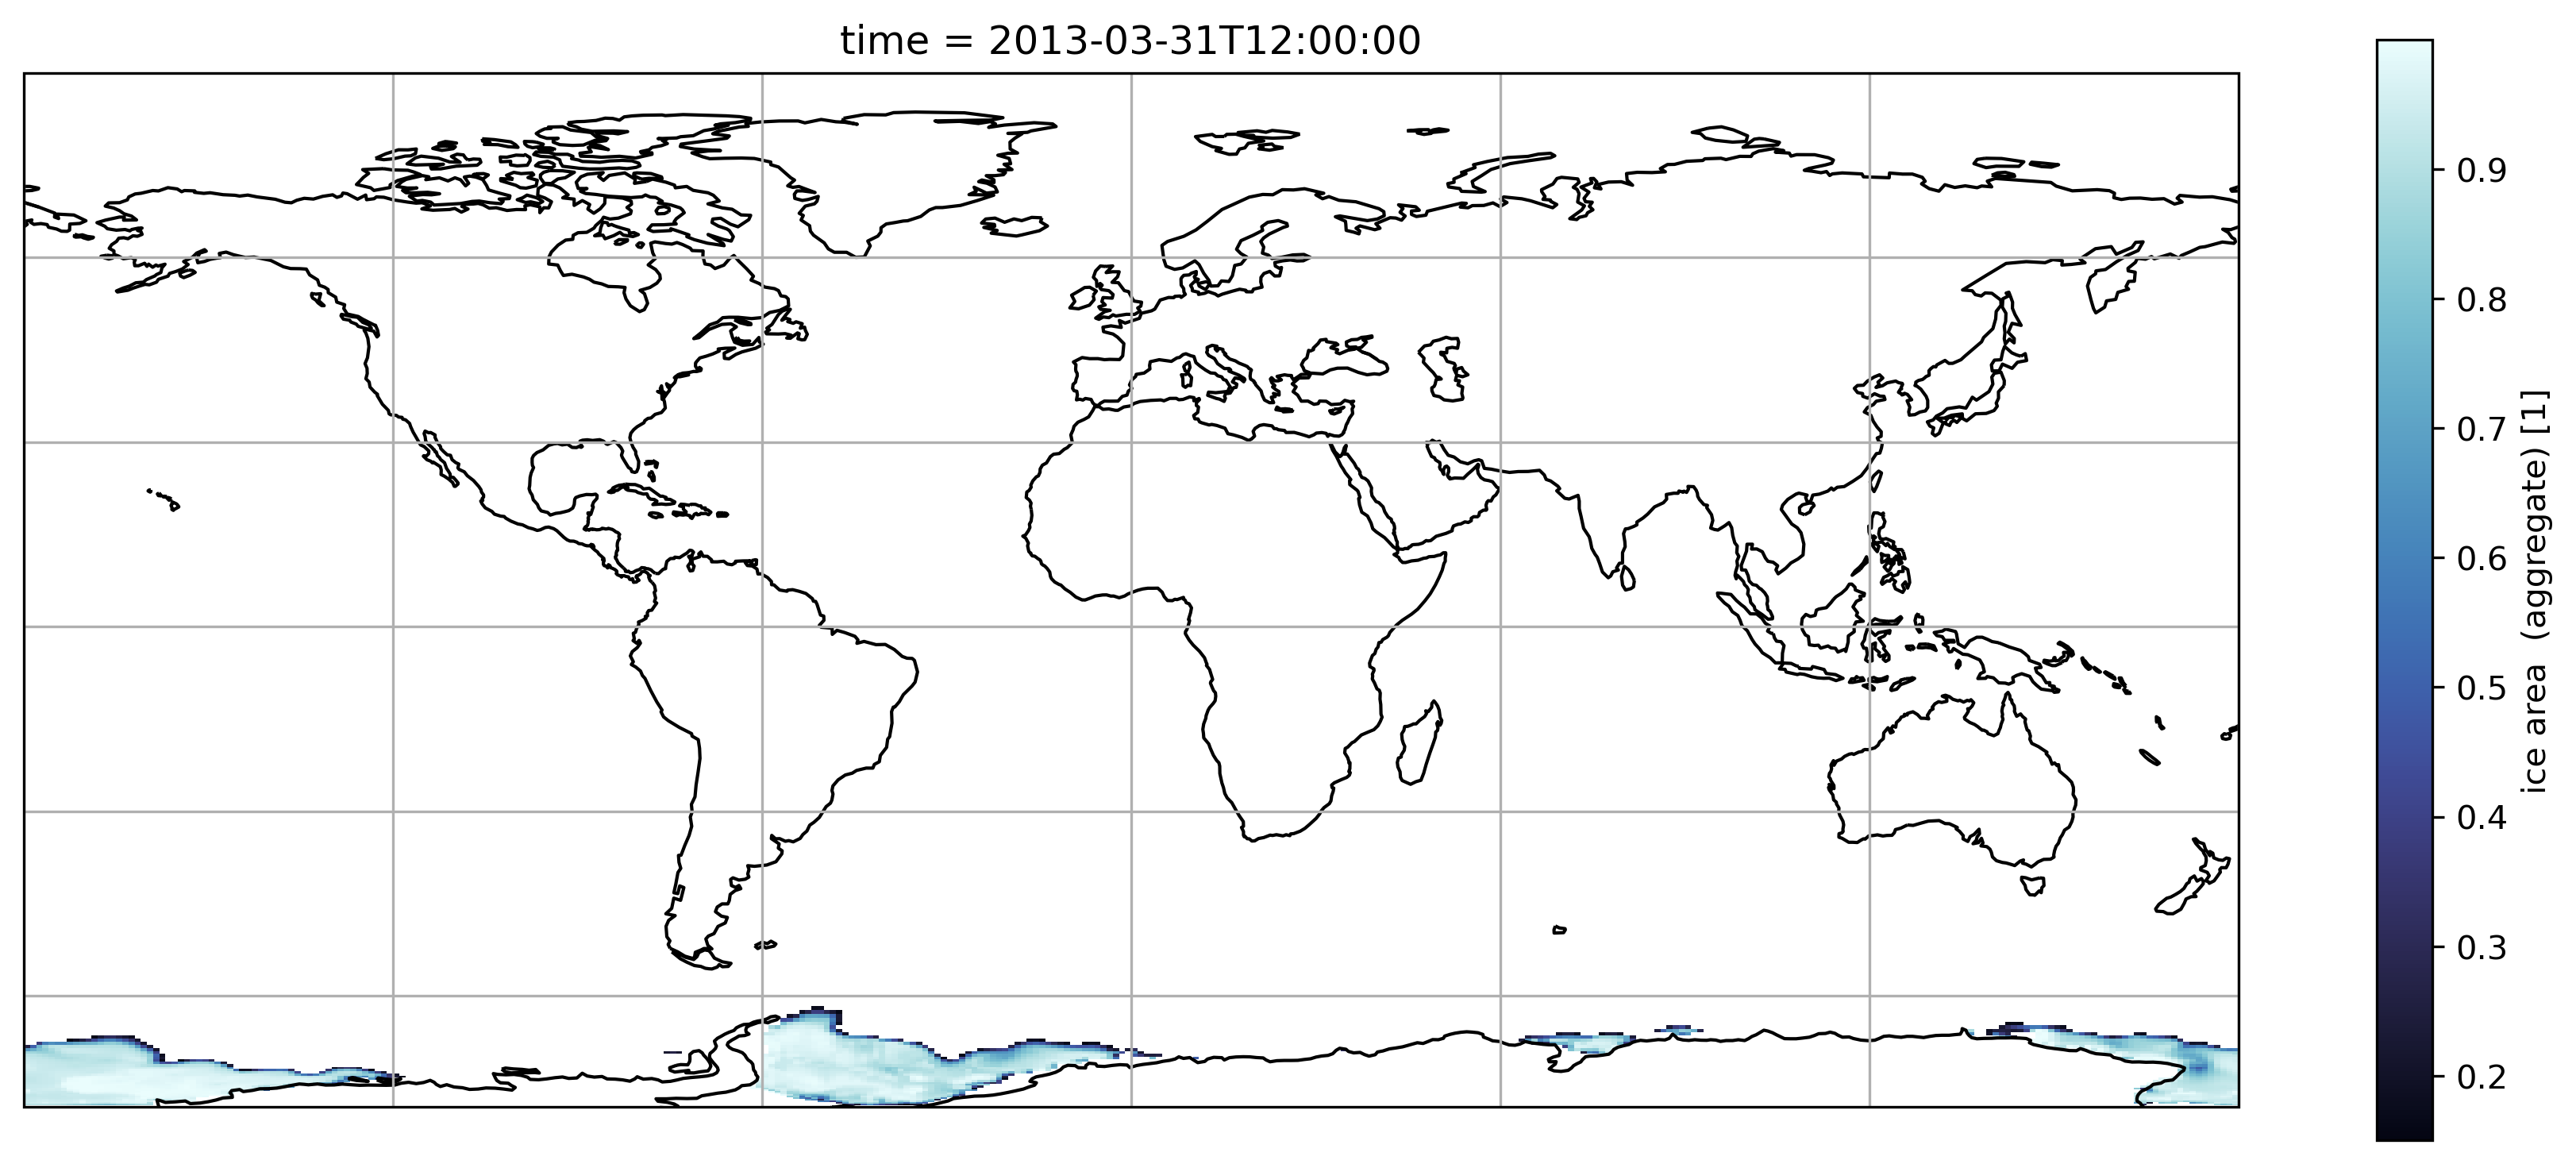

In [43]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

ds_sh["aice"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat", cmap=cmo.ice)

ax.coastlines()
_ = ax.gridlines()
# plt.savefig(plotfolder+'exampleout.png')

In [44]:
# time_idx = -1

In [45]:
bounds


array([ 0,  8, 12])

In [48]:
ds_sh['NFSD']

<xarray.DataArray 'NFSD' (nf: 12)> Size: 96B
dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(12,), chunktype=numpy.ndarray>
Dimensions without coordinates: nf

In [49]:
ds_sh['binwidths'] = ds_sh['NFSD']#.mean(dim=['time', 'nj', 'ni'])
ds_sh['binwidths'].values = BinWidths

In [50]:
ds_sh['afsd_int'] = ds_sh['afsd']*ds_sh['binwidths']

In [51]:
time_idx = -275 # -1

In [54]:
ds_sh['small_floes'] = ds_sh['afsd_int'].isel(nf=slice(bounds[0], bounds[1])).sum(dim='nf')
ds_sh['medium_floes'] = ds_sh['afsd_int'].isel(nf=slice(bounds[1], bounds[2])).sum(dim='nf')
ds_sh['large_floes'] = ds_sh['afsd_int'].isel(nf=slice(bounds[2], -1)).sum(dim='nf') #bounds[3])).sum(dim='nf')

Text(0.5, 0.985, '2012-06-30')

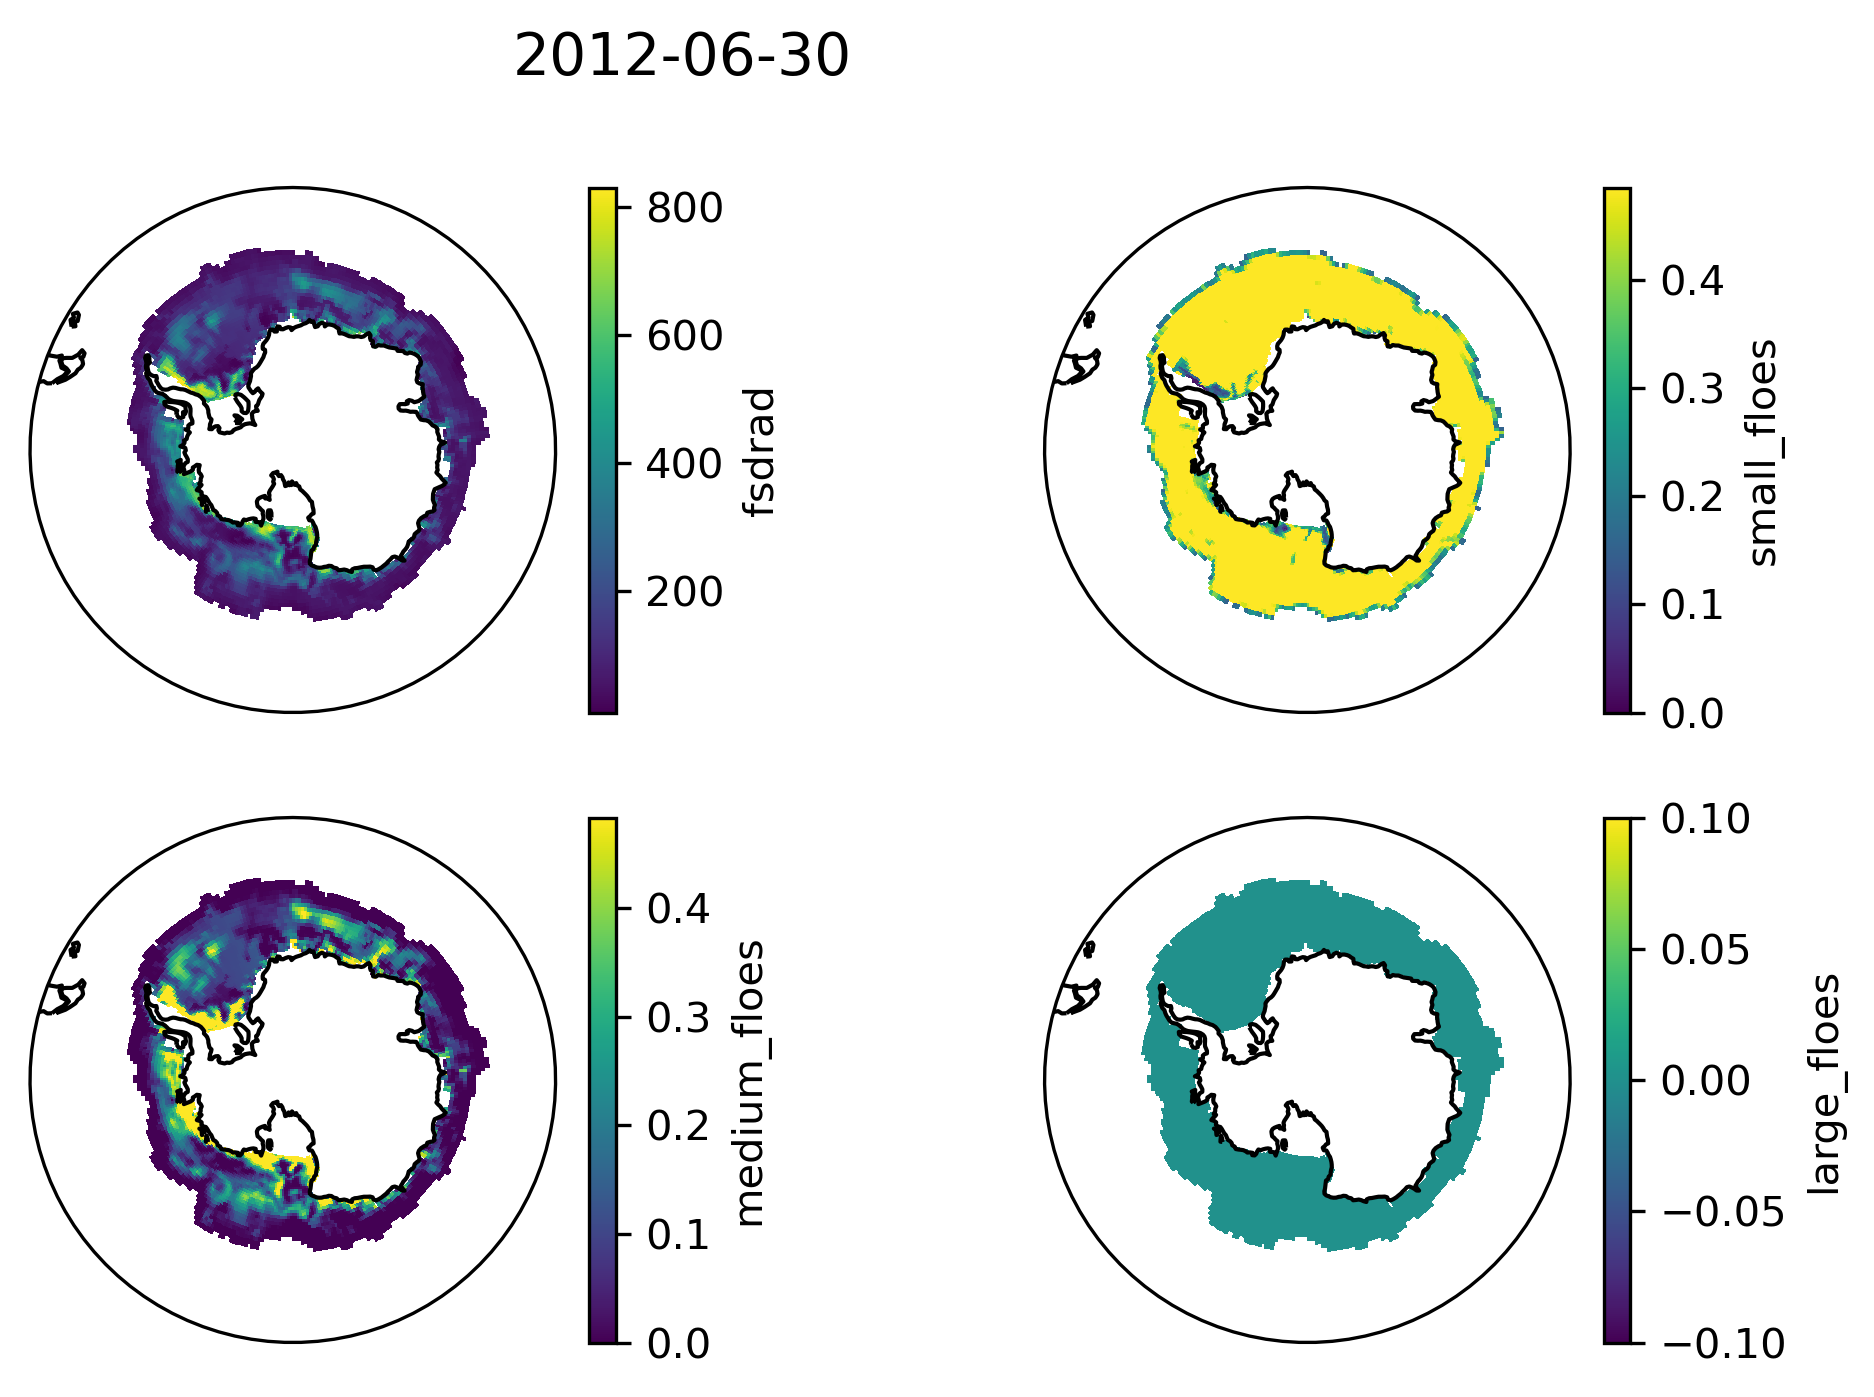

In [55]:
# create subplots with SouthPolar projection
fig, axes = plt.subplots(
    2, 2,
    figsize=(4*2, 5),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)
axes = axes.flatten()

plot_vars = ['fsdrad', 'small_floes', 'medium_floes', 'large_floes']
for i, ax in enumerate(axes):

    da = ds_sh[plot_vars[i]].where(ds_sh['aice'] > 0.15).isel(time=slice(time_idx-30, time_idx)).mean(dim='time')

    if i > 0:
        vmax = abs(da.max().values)*0.5
        vmin = 0
        img = ax.pcolormesh(
        da['geolon'], da['geolat'], da,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        cmap='viridis'
        )
    else:
        img = ax.pcolormesh(
            da['geolon'], da['geolat'], da,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )

    # individual colorbar
    cbar = fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label(plot_vars[i])

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for ax in axes.flatten():
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()
    # ax.add_feature(cfeature.LAND, facecolor='lightgray')

# cbar = fig.colorbar(
#     img,
#     ax=axes,
#     orientation='vertical',
#     fraction=0.02,
#     pad=0.04
# )
# cbar.set_label('Significant Wave Height (m)')

date = pd.to_datetime(ds_sh.isel(time=time_idx)['time'].values)
fig.suptitle(date.strftime('%Y-%m-%d'), fontsize=14, y=0.985)

In [57]:
ds_sh['small_floes_newi'] = (ds_sh['dafsd_newi']*ds_sh['binwidths']).isel(nf=slice(bounds[0], bounds[1])).sum(dim='nf')
ds_sh['medium_floes_wave'] = (ds_sh['dafsd_wave']*ds_sh['binwidths']).isel(nf=slice(bounds[1], bounds[2])).sum(dim='nf')
ds_sh['large_floes_weld'] = (ds_sh['dafsd_weld']*ds_sh['binwidths']).isel(nf=slice(bounds[2], -1)).sum(dim='nf') #bounds[3])).sum(dim='nf')

Text(0.5, 0.985, '2012-06-30')

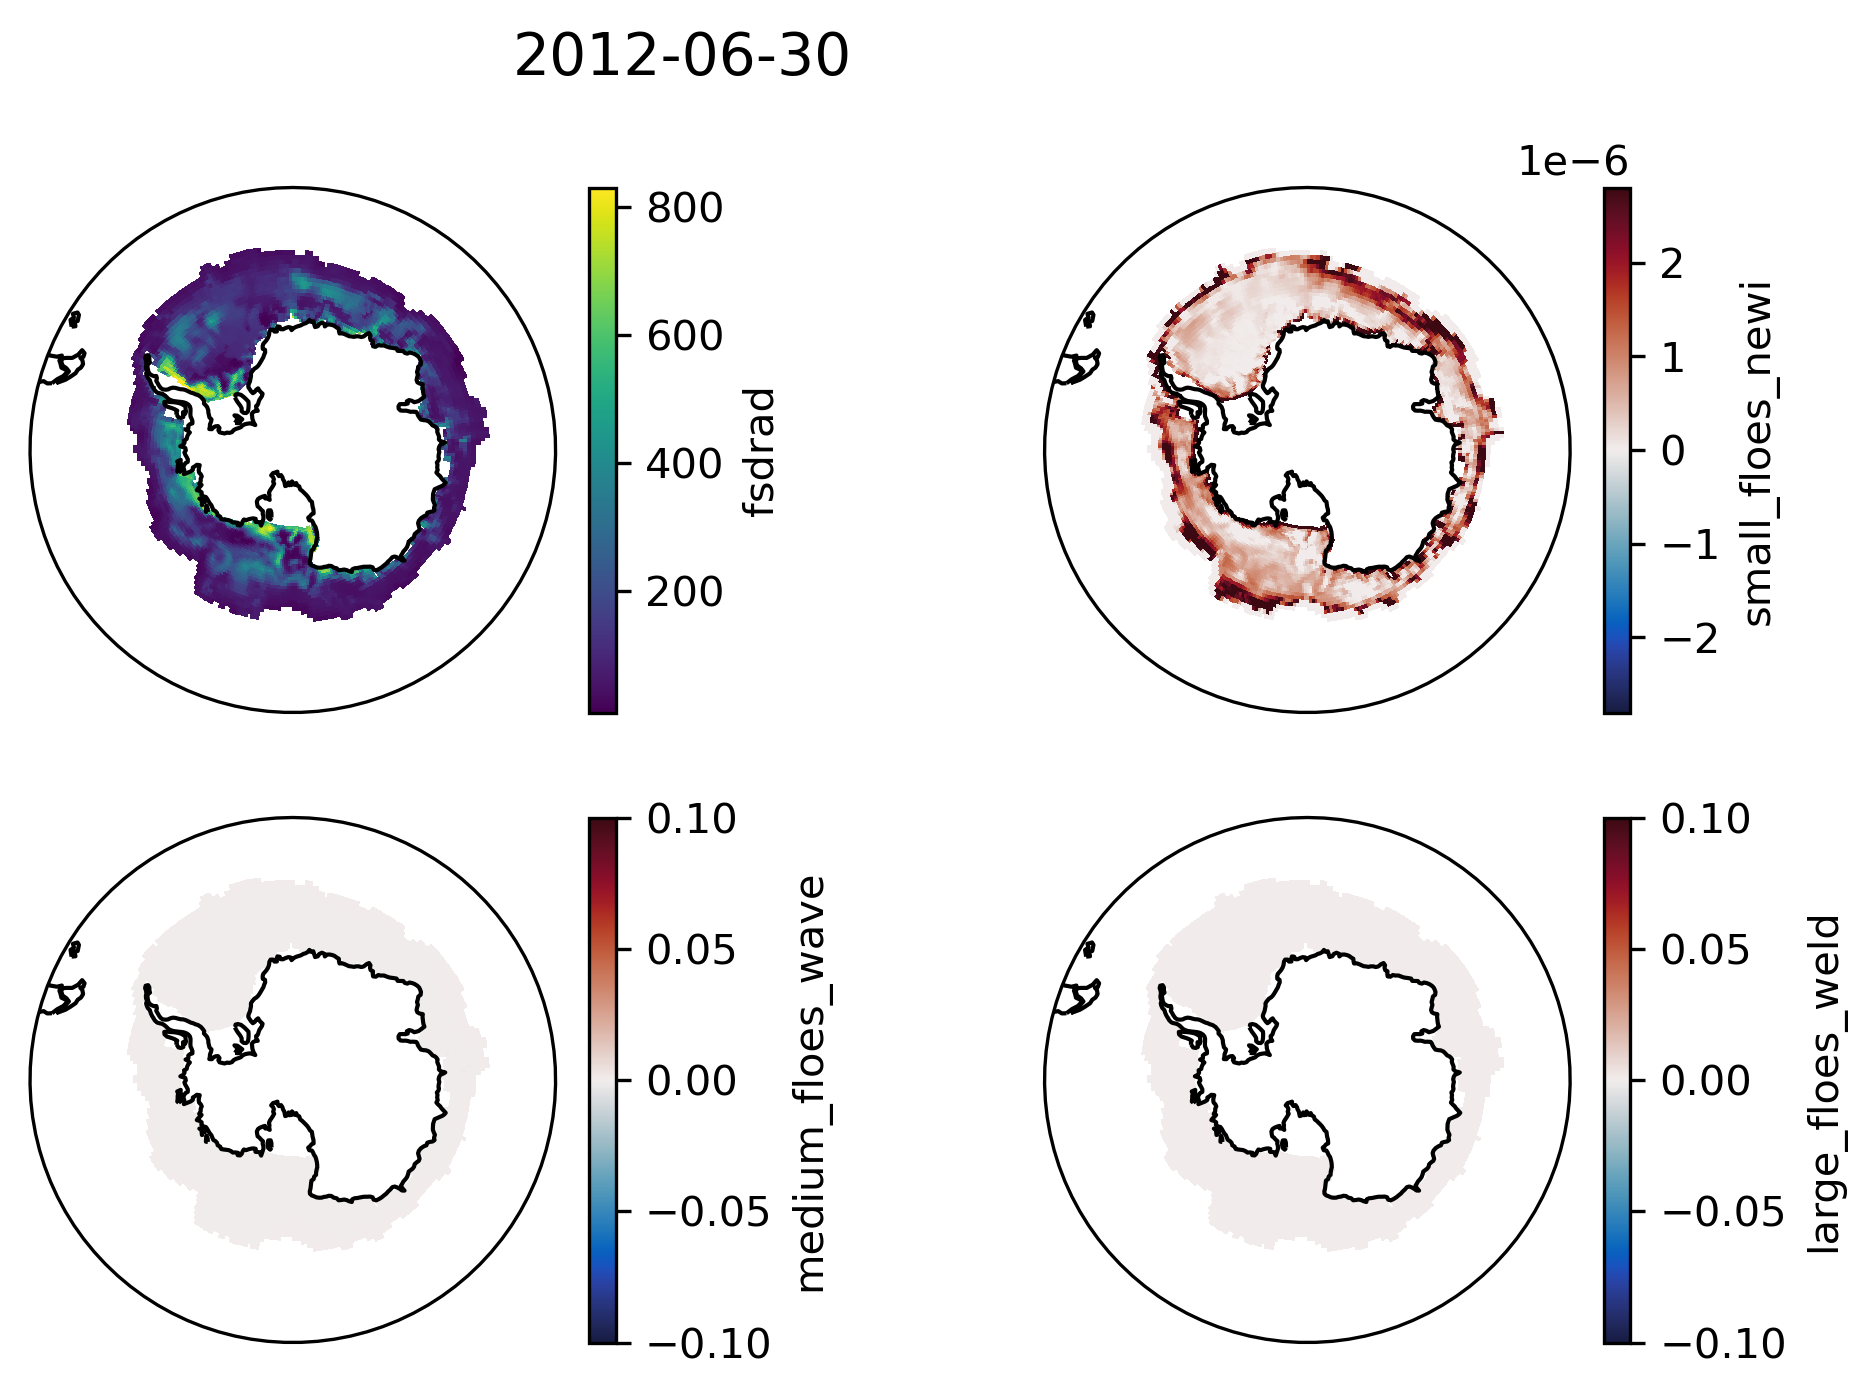

In [58]:
# create subplots with SouthPolar projection
fig, axes = plt.subplots(
    2, 2,
    figsize=(4*2, 5),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)
axes = axes.flatten()

plot_vars = ['fsdrad', 'small_floes_newi', 'medium_floes_wave', 'large_floes_weld']
for i, ax in enumerate(axes):

    da = ds_sh[plot_vars[i]].where(ds_sh['aice'] > 0.15).isel(time=slice(time_idx-30, time_idx)).mean(dim='time')
    if i > 0:
        vmax = abs(da.max().values)*0.1
        vmin = -vmax
        img = ax.pcolormesh(
        da['geolon'], da['geolat'], da,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        cmap=cmo.balance
        )
    else:
        img = ax.pcolormesh(
            da['geolon'], da['geolat'], da,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )

    # individual colorbar
    cbar = fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label(plot_vars[i])

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for ax in axes.flatten():
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()
    # ax.add_feature(cfeature.LAND, facecolor='lightgray')

# cbar = fig.colorbar(
#     img,
#     ax=axes,
#     orientation='vertical',
#     fraction=0.02,
#     pad=0.04
# )
# cbar.set_label('Significant Wave Height (m)')

date = pd.to_datetime(ds_sh.isel(time=time_idx)['time'].values)
fig.suptitle(date.strftime('%Y-%m-%d'), fontsize=14, y=0.985)

Text(0.5, 0.985, '2012-06-30')

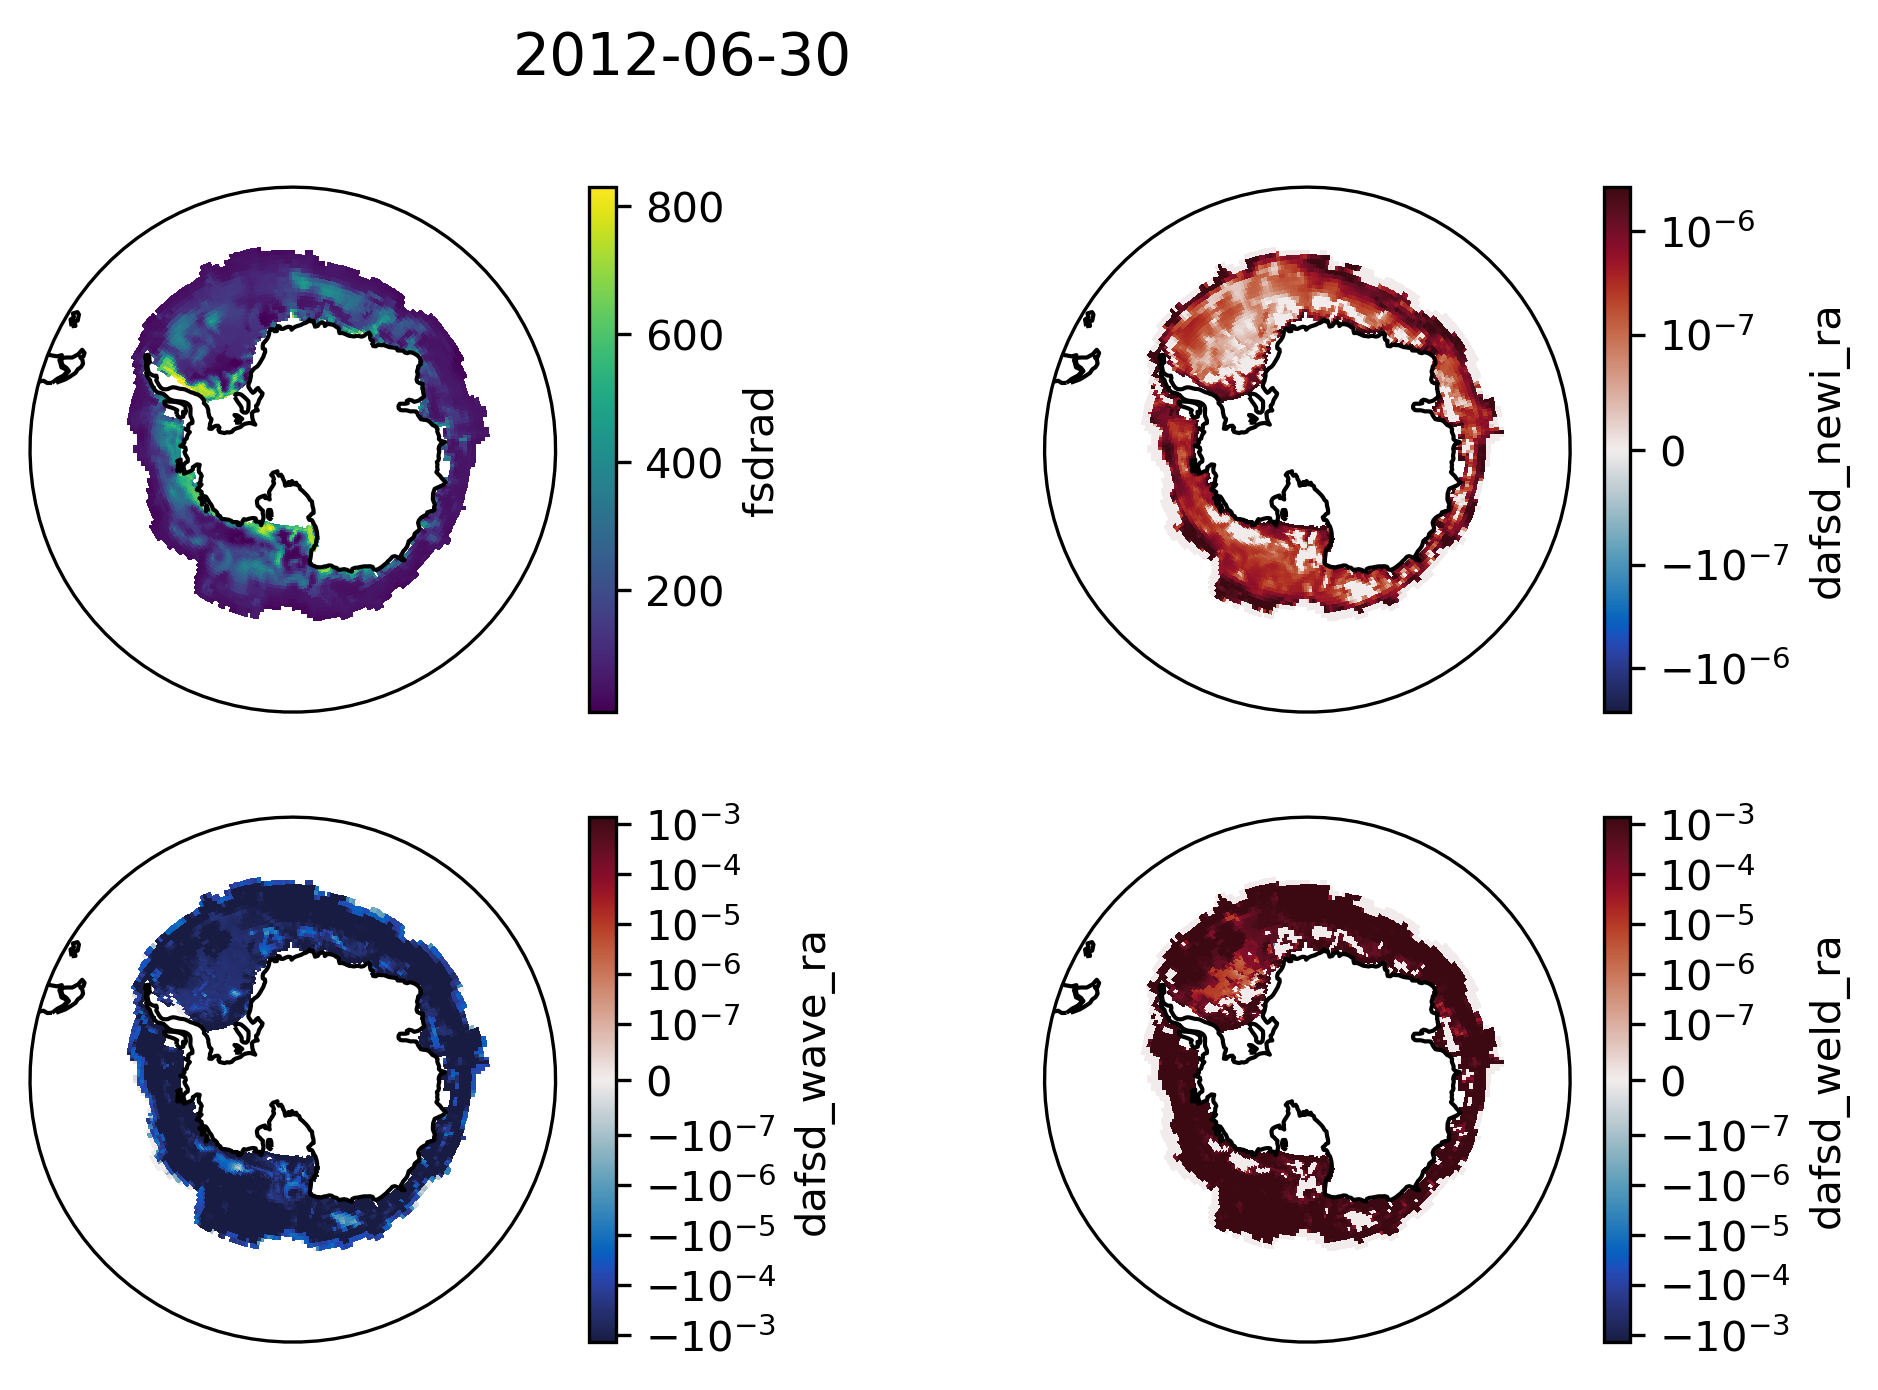

In [59]:
import matplotlib.colors as colors
# create subplots with SouthPolar projection
fig, axes = plt.subplots(
    2, 2,
    figsize=(4*2, 5),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)
axes = axes.flatten()

plot_vars = ['fsdrad', 'dafsd_newi_ra', 'dafsd_wave_ra', 'dafsd_weld_ra']
for i, ax in enumerate(axes):

    da = ds_sh[plot_vars[i]].where(ds_sh['aice'] > 0.15).isel(time=slice(time_idx-30, time_idx)).mean(dim='time')
    if i > 0:
        vmax = abs(da).max().values*0.1
        vmin = -vmax
        norm = colors.SymLogNorm(
            linthresh=1e-7,   # linear region around 0
            linscale=1.0,
            vmin=-vmax,
            vmax=vmax
        )
        img = ax.pcolormesh(
        da['geolon'], da['geolat'], da,
        norm=norm,
        transform=ccrs.PlateCarree(),
        cmap=cmo.balance
        )
    else:
        img = ax.pcolormesh(
            da['geolon'], da['geolat'], da,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )

    # individual colorbar
    cbar = fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label(plot_vars[i])

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for ax in axes.flatten():
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()
    # ax.add_feature(cfeature.LAND, facecolor='lightgray')

# cbar = fig.colorbar(
#     img,
#     ax=axes,
#     orientation='vertical',
#     fraction=0.02,
#     pad=0.04
# )
# cbar.set_label('Significant Wave Height (m)')

date = pd.to_datetime(ds_sh.isel(time=time_idx)['time'].values)
fig.suptitle(date.strftime('%Y-%m-%d'), fontsize=14, y=0.985)

In [ ]:
client.close()